<a href="https://colab.research.google.com/github/ricardoalvarezv-cpu/Memoria-LSTM-SSI/blob/main/LSTM_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM_Student — Notebook final estructurado

Este notebook corresponde a la **versión final ordenada** para el flujo de `LSTM_Student`:

1. Entrenamiento y selección final del modelo **AF** (`a_base_x`, `F_x`)
2. Entrenamiento final del modelo **Mz TRUE-only** (resultado principal)
3. Finetune **AF → Mz** con variables estimadas (experimento complementario)

## Decisiones finales adoptadas
- **AF final**: arquitectura clásica, selección por `ACTIVE_CORE`
- **Checkpoint AF final esperado**: `fold1`, `T_BACK=2048`
- **Modelo principal para `Mz`**: `A13 TRUE-only`
- **Modelo complementario**: `A15` con entradas `HAT RAW`

Las celdas descartadas o intermedias fueron removidas para dejar un flujo más limpio y reproducible.


## 1. Preparación del entorno

In [ ]:
# =========================================
# A0_PATH_SANITY
# =========================================
from pathlib import Path

ROOT = Path("/content/memoria")
assert ROOT.exists(), f"ROOT no existe: {ROOT}"

# --- auto NPZ_DIR: busca carpeta con EQ*.npz ---
cand_npz_dirs = []
for p in ROOT.iterdir():
    if p.is_dir():
        # busca al menos 1 EQ*.npz en esa carpeta
        if any(pp.name.startswith("EQ") and pp.suffix == ".npz" for pp in p.glob("*.npz")):
            cand_npz_dirs.append(p)

cand_npz_dirs = sorted(cand_npz_dirs)
print("Candidate NPZ dirs:", [p.as_posix() for p in cand_npz_dirs])

# Si solo hay 1, la usamos; si no, fallback
if len(cand_npz_dirs) == 1:
    NPZ_DIR_AUTO = cand_npz_dirs[0]
else:
    NPZ_DIR_AUTO = ROOT / "processed_step_full_v2"  # fallback

# --- auto Teacher ckpt: busca .pt en runs_notebook_B_teacher ---
B_DIR = ROOT / "runs_colab" / "runs_notebook_B_teacher"
teacher_candidates = sorted(B_DIR.glob("*.pt"))
print("Teacher candidates (.pt) last 10:", [p.name for p in teacher_candidates][-10:])

def pick_teacher_ckpt(cands):
    if not cands:
        return None
    # prioridad: ANTIBIAS > FINAL > cualquiera (último)
    for key in ["ANTIBIAS", "FINAL"]:
        for p in reversed(cands):
            if key in p.name:
                return p
    return cands[-1]

TEACHER_CKPT_AUTO = pick_teacher_ckpt(teacher_candidates)

print("NPZ_DIR_AUTO:", NPZ_DIR_AUTO)
print("TEACHER_CKPT_AUTO:", TEACHER_CKPT_AUTO)

Candidate NPZ dirs: ['/content/memoria/processed_step_full_v2']
Teacher candidates (.pt) last 10: ['TEACHER_ANTIBIAS_MZ_meanP99_dtref0.005_T1024_H256_L2_lr0.0003_lamBiasMz0.001.pt', 'TEACHER_A_WINDOWS.pt', 'TEACHER_B_FULLSEQ.pt', 'TEACHER_C_WIN_PLUS_FT.pt', 'TEACHER_FINAL_ALL_meanP99_dtref0.005_T1024_H256_L2_lr0.001.pt', 'TEACHER_FINAL_WINDOWS_OFFICIAL.pt', 'TEACHER_FROZEN_T512_H256_L2_lr0.001.pt', 'TEACHER_MULTI_dtref0.005_T1024_H256_L2_lr0.001.pt']
NPZ_DIR_AUTO: /content/memoria/processed_step_full_v2
TEACHER_CKPT_AUTO: /content/memoria/runs_colab/runs_notebook_B_teacher/TEACHER_ANTIBIAS_MZ_meanP99_dtref0.005_T1024_H256_L2_lr0.0003_lamBiasMz0.001.pt


In [ ]:
# =========================================
# A1_CONFIG_PATHS& PATHS (Notebook A - Student)  ✅ ÚNICA VERSIÓN
# =========================================
import os, json, math, random, time
from dataclasses import dataclass, asdict
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------------
# Reproducibilidad
# -------------------------
SEED = 1337

def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -------------------------
# Tiempo / Ventana
# -------------------------
DT_REF = 0.005
T_BACK = 1024

# -------------------------
# Normalización robusta (teacher/student)
# -------------------------
PCTL = 99
EPS = 1e-8
CLIP_X = 10.0
CLIP_Y = 10.0

# -------------------------
# Student I/O
# -------------------------
STUDENT_IN_IDXS = [0, 1]  # v1: vg, ag (NO cambiar)
OUT_DIM = 3               # teacher space: [a_base_x, Fx, Mz] (si el teacher tiene 3)

# -------------------------
# Training (base)
# -------------------------
BATCH_SIZE = 16
LR = 3e-4
MAX_EPOCHS = 60
GRAD_CLIP_NORM = 1.0

K_TRAIN_PER_EVENT = 96
K_VAL_PER_EVENT   = 64

PATIENCE = 10
MIN_DELTA = 0.0

# distillation regularizers (opcionales)
LAM_SCALE = 0.1
LAM_BIAS  = 0.0

# eval / plotting
EVAL_STRIDE = 16

# ACTIVE window (para métricas/plots)
ACTIVE_ONSET_PCT = 0.05
ACTIVE_TAIL_PCT  = 0.02
ACTIVE_WARMUP_S  = 1.0
ACTIVE_MARGIN_END_S = 0.5

# cache stride (si lo usas en tu dataset/sampler)
TEACHER_STRIDE_CACHE = int(globals().get("TEACHER_STRIDE_CACHE", 128))

# dataloader
NUM_WORKERS = 0  # Colab estable

# -------------------------
# Paths
# -------------------------
ROOT = Path("/content/memoria")
RUNS_DIR_A = ROOT / "runs_colab" / "runs_notebook_A_student"
RUNS_DIR_A.mkdir(parents=True, exist_ok=True)

NPZ_DIR = globals().get("NPZ_DIR_AUTO", ROOT / "processed_step_full_v2")
TEACHER_CKPT = globals().get(
    "TEACHER_CKPT_AUTO",
    ROOT / "runs_colab" / "runs_notebook_B_teacher" / "TEACHER_FINAL_ALL_meanP99_dtref0.005_T1024_H256_L2_lr0.001.pt"
)

print("NPZ_DIR:", NPZ_DIR, "| exists:", Path(NPZ_DIR).exists())
print("RUNS_DIR_A:", RUNS_DIR_A)
print("TEACHER_CKPT:", TEACHER_CKPT, "| exists:", Path(TEACHER_CKPT).exists())

assert Path(NPZ_DIR).exists(), f"NPZ_DIR no existe: {NPZ_DIR}"
assert Path(TEACHER_CKPT).exists(), f"TEACHER_CKPT no existe: {TEACHER_CKPT}"

device: cuda
NPZ_DIR: /content/memoria/processed_step_full_v2 | exists: True
RUNS_DIR_A: /content/memoria/runs_colab/runs_notebook_A_student
TEACHER_CKPT: /content/memoria/runs_colab/runs_notebook_B_teacher/TEACHER_ANTIBIAS_MZ_meanP99_dtref0.005_T1024_H256_L2_lr0.0003_lamBiasMz0.001.pt | exists: True


## 2. Teacher y utilidades base

In [ ]:
# =========================================
# A2_TEACHER_LOAD_AND_PREDICTÚNICA VERSIÓN
# =========================================
import numpy as np
import torch
import torch.nn as nn

def load_teacher_ckpt(path: str, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location, weights_only=False)
    if not isinstance(ckpt, dict) or ("state_dict" not in ckpt) or ("cfg" not in ckpt):
        raise ValueError("Checkpoint Teacher debe ser dict con keys: {'state_dict','cfg'}.")
    return ckpt

class SeqTeacher(nn.Module):
    def __init__(self, in_dim=5, hid=256, layers=2, dropout=0.0, out_dim=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=hid,
            num_layers=layers,
            dropout=dropout if layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hid, out_dim)

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.head(h)

def _to_1d(a, n_expected: int, name: str):
    a = np.array(a, dtype=np.float32)
    if a.size != n_expected:
        raise ValueError(f"{name} size={a.size} != {n_expected}. shape={a.shape}")
    return a.reshape(-1).astype(np.float32)

# ---- load ckpt ----
teacher_ckpt = load_teacher_ckpt(str(TEACHER_CKPT), map_location="cpu")
cfg_t = teacher_ckpt["cfg"]

# --- Sanity temporal ---
assert abs(float(cfg_t["dt_ref"]) - DT_REF) < 1e-12, f"Teacher dt_ref={cfg_t['dt_ref']} != DT_REF={DT_REF}"
assert int(cfg_t["T_back"]) == T_BACK, f"Teacher T_back={cfg_t['T_back']} != T_BACK={T_BACK}"

# --- Build teacher model ---
teacher = SeqTeacher(
    in_dim=int(cfg_t.get("in_dim", 5)),
    hid=int(cfg_t["hid"]),
    layers=int(cfg_t["layers"]),
    dropout=float(cfg_t.get("dropout", 0.0)),
    out_dim=int(cfg_t.get("out_dim", 3)),
)
teacher.load_state_dict(teacher_ckpt["state_dict"], strict=True)
teacher.eval().to(device)

# --- Extract scalers EXACTOS del teacher (force 1D) ---
TXM   = _to_1d(cfg_t["XM"], 5, "XM")               # (5,)
TXP99 = _to_1d(cfg_t["X_P99ABS"], 5, "X_P99ABS")   # (5,)
TYM   = _to_1d(cfg_t["YM"], 3, "YM")               # (3,)
TYP99 = _to_1d(cfg_t["Y_P99ABS"], 3, "Y_P99ABS")   # (3,)

TCLIP_X = float(cfg_t.get("CLIP_X", CLIP_X))
TCLIP_Y = float(cfg_t.get("CLIP_Y", CLIP_Y))

# Alias estándar (evita NameError)
teacher_model = teacher

print("Teacher loaded OK")
print("Teacher cfg:", {k: cfg_t.get(k) for k in ["dt_ref","T_back","hid","layers","dropout","in_dim","out_dim"]})
print("TXM:", TXM.shape, "TXP99:", TXP99.shape, "| TYM:", TYM.shape, "TYP99:", TYP99.shape)
print("TCLIP_X/Y:", TCLIP_X, TCLIP_Y)

def denorm_teacher_to_phys(Yn_teacher: np.ndarray):
    """Convierte teacher-space -> phys usando (TYM, TYP99)."""
    Yn_teacher = np.asarray(Yn_teacher, dtype=np.float32)
    return (Yn_teacher * (TYP99.reshape(1,-1) + EPS) + TYM.reshape(1,-1)).astype(np.float32)

def normalize_phys_to_teacher(Y_phys: np.ndarray):
    """Convierte phys -> teacher-space usando (TYM, TYP99)."""
    Y_phys = np.asarray(Y_phys, dtype=np.float32)
    Yn = (Y_phys - TYM.reshape(1,-1)) / (TYP99.reshape(1,-1) + EPS)
    Yn = np.clip(Yn, -TCLIP_Y, TCLIP_Y).astype(np.float32)
    return np.nan_to_num(Yn, nan=0.0, posinf=0.0, neginf=0.0)

@torch.no_grad()
def teacher_predict_event_full_teacher_space(Xr_full: np.ndarray, stride: int = 1):
    """
    Predice salida del teacher en ESPACIO teacher (lo que el teacher entrega).
    - Normaliza X con TXM/TXP99 y clipea.
    - Agrega por ventanas con solape (promedio).
    - Robusto a out_dim real (1/2/3/...)
    Retorna: (NT, out_dim_teacher)
    """
    teacher_model.eval().to(device)

    X = np.asarray(Xr_full, dtype=np.float32)
    Xn = (X - TXM.reshape(1,-1)) / (TXP99.reshape(1,-1) + EPS)
    Xn = np.clip(Xn, -TCLIP_X, TCLIP_X)
    Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    NT = int(Xn.shape[0])
    last0 = max(0, NT - T_BACK)

    t0s = list(range(0, max(1, NT - T_BACK + 1), stride))
    if len(t0s) == 0 or t0s[-1] != last0:
        t0s.append(last0)

    y_sum = None
    y_cnt = np.zeros((NT, 1), dtype=np.float32)

    for t0 in t0s:
        win = Xn[t0:t0+T_BACK, :]
        if win.shape[0] < T_BACK:
            pad = np.repeat(win[-1:, :], T_BACK - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).to(device=device, dtype=torch.float32)
        yh = teacher_model(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)  # (T, C) o (T,)

        if yh.ndim == 1:
            yh = yh[:, None]
        if y_sum is None:
            out_dim = int(yh.shape[1])
            y_sum = np.zeros((NT, out_dim), dtype=np.float32)

        t1 = min(NT, t0 + T_BACK)
        y_sum[t0:t1, :] += yh[:(t1 - t0), :]
        y_cnt[t0:t1, :] += 1.0

    y_cnt[y_cnt == 0] = 1.0
    yhat = y_sum / y_cnt
    return np.nan_to_num(yhat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

Teacher loaded OK
Teacher cfg: {'dt_ref': 0.005, 'T_back': 1024, 'hid': 256, 'layers': 2, 'dropout': 0.0, 'in_dim': None, 'out_dim': None}
TXM: (5,) TXP99: (5,) | TYM: (3,) TYP99: (3,)
TCLIP_X/Y: 10.0 10.0


In [ ]:
# =========================================
# A3_RESAMPLING_UTILS> DT_REF)
# =========================================
import numpy as np

def moving_average(x: np.ndarray, win: int = 3):
    """Centered moving average (per channel)."""
    if win <= 1:
        return x
    pad = win // 2
    xp = np.pad(x, ((pad, pad), (0, 0)), mode="edge")
    k = np.ones(win, dtype=np.float32) / float(win)
    out = np.zeros_like(x, dtype=np.float32)
    for c in range(x.shape[1]):
        out[:, c] = np.convolve(xp[:, c], k, mode="valid")
    return out

def resample_to_dtref(X: np.ndarray, Y: np.ndarray, dt: float, dt_ref: float):
    """
    Linear interpolation per channel to dt_ref.
    If downsample (dt_ref > dt): apply smoothing before interpolation (anti-alias-ish).
    """
    assert X.ndim == 2 and Y.ndim == 2, f"X/Y deben ser 2D. got {X.ndim}, {Y.ndim}"
    NT = X.shape[0]
    if NT < 2:
        return X.astype(np.float32), Y.astype(np.float32)

    t_old = np.arange(NT, dtype=np.float64) * float(dt)
    t_end = float(t_old[-1])

    NT2 = int(np.floor(t_end / float(dt_ref))) + 1
    NT2 = max(NT2, 2)
    t_new = np.arange(NT2, dtype=np.float64) * float(dt_ref)

    X_use, Y_use = X, Y
    if dt_ref > dt:
        # suaviza SOLO señales del contacto (d_mid, v_mid, a_mid),
        # pero deja vg/ag intactos
        X_use = X.copy()

        def moving_average_1d(x, w):
            if w <= 1:
                return x
            kernel = np.ones(w, dtype=np.float64) / float(w)
            return np.convolve(x, kernel, mode="same")

        win = 5  # puedes probar 3 también
        for j in [2, 3, 4]:
            X_use[:, j] = moving_average_1d(X_use[:, j], win)

        # Y: normalmente NO lo suavices (queremos evaluar/entrenar contra la señal real)
        Y_use = Y
    else:
        X_use = X
        Y_use = Y

    Xr = np.zeros((NT2, X.shape[1]), dtype=np.float32)
    Yr = np.zeros((NT2, Y.shape[1]), dtype=np.float32)

    for c in range(X.shape[1]):
        Xr[:, c] = np.interp(t_new, t_old, X_use[:, c]).astype(np.float32)
    for c in range(Y.shape[1]):
        Yr[:, c] = np.interp(t_new, t_old, Y_use[:, c]).astype(np.float32)

    return Xr, Yr

## 3. Datos, splits y preprocesamiento

In [ ]:
# =========================================
# A4_LIST_FILES_AND_SPLITSÚNICA
#   - Usa NPZ_DIR de A1
#   - Define ALL_FILES (compat)
#   - Resuelve OOD por record_id (rid)
#   - NO revienta si falta OOD: avisa y sigue
# =========================================
import numpy as np
from pathlib import Path
from sklearn.model_selection import GroupKFold

assert "NPZ_DIR" in globals(), "Falta NPZ_DIR (corre A1)."
assert Path(NPZ_DIR).exists(), f"NPZ_DIR no existe: {NPZ_DIR}"

# ---------- listar npz ----------
ALL_FILES = sorted(list(Path(NPZ_DIR).glob("*.npz")))  # alias compat
assert len(ALL_FILES) > 0, f"No encontré .npz en {NPZ_DIR}"

def _get_rid_only(path: Path) -> str:
    d = np.load(path, allow_pickle=True)
    if "record_id" in d:
        try:
            return str(d["record_id"])
        except Exception:
            return str(np.array(d["record_id"]).reshape(()))
    return path.stem

# ---------- index rid -> file ----------
rid_to_file = {}
dups = []
for p in ALL_FILES:
    rid = _get_rid_only(p)
    if rid in rid_to_file:
        dups.append(rid)
    rid_to_file[rid] = p

if dups:
    print("[A4] WARNING: rids duplicados (se queda el último):", sorted(set(dups))[:10], "...")
print("[A4] ALL_FILES =", len(ALL_FILES), "| unique RIDs =", len(rid_to_file))

# ---------- define OOD ----------
OOD_RIDS = ["EQ007", "EQ019", "EQ052", "EQ081"]  # <-- tus OOD
OOD_FILES = [rid_to_file[r] for r in OOD_RIDS if r in rid_to_file]
OOD_FOUND = [_get_rid_only(p) for p in OOD_FILES]
OOD_MISSING = [r for r in OOD_RIDS if r not in rid_to_file]

print("[A4] OOD_RIDS requested:", OOD_RIDS)
print("[A4] OOD_RIDS found     :", OOD_FOUND)
if OOD_MISSING:
    print("[A4] WARNING: faltan OOD en NPZ_DIR:", OOD_MISSING)
    print("[A4] Tip: imprime lista de rids disponibles con: sorted(list(rid_to_file.keys()))[:50]")

# ---------- CV files (todo excepto OOD encontrados) ----------
OOD_SET = set(OOD_FOUND)
CV_FILES = [p for p in ALL_FILES if _get_rid_only(p) not in OOD_SET]

print("[A4] CV_FILES =", len(CV_FILES), "| OOD_FILES =", len(OOD_FILES))

# ---------- groups (GroupKFold sobre eventos) ----------
groups = np.array([_get_rid_only(p) for p in CV_FILES], dtype=object)
X_dummy = np.zeros((len(CV_FILES), 1), dtype=np.float32)  # placeholder

# Pre-build folds_files: list[(train_files, val_files)]
K_FOLDS = 5
gkf = GroupKFold(n_splits=K_FOLDS)

folds_files = []
for fold_id, (tr_idx, va_idx) in enumerate(gkf.split(X_dummy, y=None, groups=groups)):
    tr_files = [CV_FILES[i] for i in tr_idx]
    va_files = [CV_FILES[i] for i in va_idx]
    folds_files.append((tr_files, va_files))

print(f"[A4] GroupKFold ready | K_FOLDS={K_FOLDS} | folds_files={len(folds_files)}")
print("[A4] Example fold0 sizes:", len(folds_files[0][0]), "(train) /", len(folds_files[0][1]), "(val)")

[A4] ALL_FILES = 84 | unique RIDs = 84
[A4] OOD_RIDS requested: ['EQ007', 'EQ019', 'EQ052', 'EQ081']
[A4] OOD_RIDS found     : ['EQ007', 'EQ019', 'EQ052', 'EQ081']
[A4] CV_FILES = 80 | OOD_FILES = 4
[A4] GroupKFold ready | K_FOLDS=5 | folds_files=5
[A4] Example fold0 sizes: 64 (train) / 16 (val)


In [ ]:
# =========================================
# A5_ROBUST_SCALER
# =========================================
import numpy as np
from dataclasses import dataclass

@dataclass
class RobustScalerP99:
    xm: np.ndarray
    xp99: np.ndarray
    ym: np.ndarray
    yp99: np.ndarray
    eps: float = EPS
    clip_x: float = CLIP_X
    clip_y: float = CLIP_Y

def fit_scaler_mean_p99(train_files, dt_ref=DT_REF, pctl=PCTL):
    """
    Fit on TRAIN only (full resampled sequences, concatenated).
    """
    Xs, Ys = [], []
    for f in train_files:
        X, Y, dt, _ = load_event_npz(f)
        Xr, Yr = resample_to_dtref(X, Y, dt, dt_ref)
        Xs.append(Xr)
        Ys.append(Yr)

    Xcat = np.concatenate(Xs, axis=0)
    Ycat = np.concatenate(Ys, axis=0)

    xm = Xcat.mean(axis=0)
    ym = Ycat.mean(axis=0)

    xp99 = np.percentile(np.abs(Xcat - xm), pctl, axis=0).astype(np.float32) + EPS
    yp99 = np.percentile(np.abs(Ycat - ym), pctl, axis=0).astype(np.float32) + EPS

    return RobustScalerP99(
        xm=xm.astype(np.float32),
        xp99=xp99,
        ym=ym.astype(np.float32),
        yp99=yp99,
        eps=EPS,
        clip_x=CLIP_X,
        clip_y=CLIP_Y,
    )

def transform_XY(Xr, Yr, sc: RobustScalerP99):
    Xn = (Xr - sc.xm) / (sc.xp99 + sc.eps)
    Yn = (Yr - sc.ym) / (sc.yp99 + sc.eps)

    Xn = np.clip(Xn, -sc.clip_x, sc.clip_x).astype(np.float32)
    Yn = np.clip(Yn, -sc.clip_y, sc.clip_y).astype(np.float32)

    Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)
    Yn = np.nan_to_num(Yn, nan=0.0, posinf=0.0, neginf=0.0)
    return Xn, Yn


In [ ]:
# =========================================
# A6_ACTIVE_UTILSínimos para estabilidad del notebook (AF)
#   - find_active_strict (con CAP de duración)
#   - alias teacher_predict_event_cache
#   - safe defaults de ACTIVE params
# =========================================
import numpy as np
from pathlib import Path

def load_event_npz(path):
    """
    Retorna: X, Y, dt, rid
    X: (NT,5) float32  -> X_full
    Y: (NT,3) float32  -> Y_full
    dt: float
    rid: str
    """
    path = Path(path)
    d = np.load(path, allow_pickle=True)

    if "X_full" not in d or "Y_full" not in d:
        raise KeyError(f"{path.name}: faltan keys 'X_full'/'Y_full'. Keys={list(d.keys())}")

    X = d["X_full"].astype(np.float32)
    Y = d["Y_full"].astype(np.float32)

    dt = float(d["dt"]) if "dt" in d else float(globals().get("DT_REF", 0.005))

    if "record_id" in d:
        rid = str(d["record_id"])
    else:
        rid = path.stem

    return X, Y, dt, rid

print("[A4_CORE] load_event_npz OK")

# ---- Safe defaults (si no están arriba) ----
if "DT_REF" not in globals():
    DT_REF = 0.005
if "EPS" not in globals():
    EPS = 1e-8

if "ACTIVE_ONSET_PCT" not in globals():
    ACTIVE_ONSET_PCT = 0.05
if "ACTIVE_TAIL_PCT" not in globals():
    ACTIVE_TAIL_PCT = 0.02
if "ACTIVE_WARMUP_S" not in globals():
    ACTIVE_WARMUP_S = 1.0
if "ACTIVE_MARGIN_END_S" not in globals():
    ACTIVE_MARGIN_END_S = 0.0

# ---- NUEVO: caps para que ACTIVE no se vaya a 270 s ----
# Recomendación inicial: 60–80 s. Prueba 80 s primero si tus eventos son largos.
if "ACTIVE_MAX_LEN_S" not in globals():
    ACTIVE_MAX_LEN_S = 80.0   # <= CAMBIA AQUÍ (80s recomendado)
if "ACTIVE_MIN_LEN_S" not in globals():
    ACTIVE_MIN_LEN_S = 10.0   # evita ventanas demasiado cortas (opcional)

def find_active_strict(y_abx: np.ndarray, dt_ref: float):
    """
    y_abx: 1D (idealmente teacher-norm o true-norm consistente con tu criterio)
    retorna: i0,i1 (con warmup, margin y cap de duración)
    """
    a = np.abs(np.asarray(y_abx, dtype=np.float64))
    NT = int(a.shape[0])
    if NT <= 2:
        return 0, NT

    peak = float(a.max())
    if not np.isfinite(peak) or peak < 1e-12:
        # señal plana -> devolvemos ventana corta al inicio
        i0 = 0
        i1 = min(NT, max(2, int(round(ACTIVE_MIN_LEN_S / dt_ref))))
        return i0, i1

    onset_thr = float(ACTIVE_ONSET_PCT * (peak + 1e-12))
    tail_thr  = float(ACTIVE_TAIL_PCT  * (peak + 1e-12))

    idx_on = int(np.argmax(a >= onset_thr)) if np.any(a >= onset_thr) else 0
    if np.any(a >= tail_thr):
        idx_tail = int(np.max(np.where(a >= tail_thr)[0]))
    else:
        idx_tail = NT - 1

    warm = int(round(float(ACTIVE_WARMUP_S) / float(dt_ref)))
    marg = int(round(float(ACTIVE_MARGIN_END_S) / float(dt_ref)))

    i0 = min(NT - 1, idx_on + warm)
    i1 = max(i0 + 1, idx_tail - marg)

    # ---- mínimo de duración (opcional) ----
    min_len = int(round(float(ACTIVE_MIN_LEN_S) / float(dt_ref)))
    if min_len > 0:
        i1 = max(i1, i0 + min_len)

    # ---- CAP máximo de duración (CLAVE) ----
    max_len = int(round(float(ACTIVE_MAX_LEN_S) / float(dt_ref)))
    if max_len > 0:
        i1 = min(i1, i0 + max_len)

    i1 = min(NT, i1)
    if i1 <= i0:
        i1 = min(NT, i0 + 2)

    return int(idx_on), int(i0), int(i1)

# ---- Alias para evitar NameError por versiones antiguas ----
def teacher_predict_event_cache(Xr_full, stride=128):
    if "teacher_predict_event_full_teacher_space" not in globals():
        raise NameError("No existe teacher_predict_event_full_teacher_space. Corre A2/A6 primero.")
    return teacher_predict_event_full_teacher_space(Xr_full, stride=stride)

print("[A5_UTILS] OK",
      "| ONSET=", ACTIVE_ONSET_PCT,
      "TAIL=", ACTIVE_TAIL_PCT,
      "WARMUP_S=", ACTIVE_WARMUP_S,
      "MARGIN_END_S=", ACTIVE_MARGIN_END_S,
      "| MIN_LEN_S=", ACTIVE_MIN_LEN_S,
      "MAX_LEN_S=", ACTIVE_MAX_LEN_S)

[A4_CORE] load_event_npz OK
[A5_UTILS] OK | ONSET= 0.05 TAIL= 0.02 WARMUP_S= 1.0 MARGIN_END_S= 0.5 | MIN_LEN_S= 10.0 MAX_LEN_S= 80.0


## 4. Cache y dataset para AF

In [ ]:
# =========================================
# A7_TEACHER_TARGET_CACHEón robusta
#   - no depende de OUT_DIM global (lo infiere)
# =========================================
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import time

TEACHER_STRIDE_CACHE = 128  # puedes bajar a 64/32 si quieres targets teacher más finos

# infer OUT_DIM teacher
if "cfg_t" in globals():
    _OUT_DIM = int(cfg_t.get("out_dim", 3))
else:
    _OUT_DIM = 3

@torch.no_grad()
def teacher_predict_event_full_teacher_space(Xr_full: np.ndarray, stride: int = 1):
    """
    Predice salida del teacher en ESPACIO teacher (lo que el teacher entrega).
    - Normaliza X con TXM/TXP99 y clipea.
    - Agrega por ventanas con solape (promedio).
    - Robusto a out_dim real (1/2/3/...)
    Retorna: (NT, out_dim_teacher)
    """
    teacher_model.eval().to(device)

    X = np.asarray(Xr_full, dtype=np.float32)
    Xn = (X - TXM.reshape(1,-1)) / (TXP99.reshape(1,-1) + EPS)
    Xn = np.clip(Xn, -TCLIP_X, TCLIP_X)
    Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    NT = int(Xn.shape[0])
    last0 = max(0, NT - T_BACK)

    t0s = list(range(0, max(1, NT - T_BACK + 1), stride))
    if len(t0s) == 0 or t0s[-1] != last0:
        t0s.append(last0)

    y_sum = None
    y_cnt = np.zeros((NT, 1), dtype=np.float32)

    for t0 in t0s:
        win = Xn[t0:t0+T_BACK, :]
        if win.shape[0] < T_BACK:
            pad = np.repeat(win[-1:, :], T_BACK - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).to(device=device, dtype=torch.float32)
        yh = teacher_model(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)  # (T, C) o (T,)

        if yh.ndim == 1:
            yh = yh[:, None]
        if y_sum is None:
            out_dim = int(yh.shape[1])
            y_sum = np.zeros((NT, out_dim), dtype=np.float32)

        t1 = min(NT, t0 + T_BACK)
        y_sum[t0:t1, :] += yh[:(t1 - t0), :]
        y_cnt[t0:t1, :] += 1.0

    y_cnt[y_cnt == 0] = 1.0
    yhat = y_sum / y_cnt
    return np.nan_to_num(yhat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

class BalancedEventWindows(Dataset):
    def __init__(self, files, scaler_student, mode="train",
                 K_per_event=64, seed=123, dt_ref=DT_REF, t_back=1024,
                 student_in_idxs=(0,1)):
        super().__init__()
        self.files = list(files)
        self.scaler_student = scaler_student
        self.mode = str(mode)
        self.K = int(K_per_event)
        self.seed = int(seed)
        self.dt_ref = float(dt_ref)
        self.t_back = int(t_back)
        self.student_in_idxs = list(student_in_idxs)

        self.cache = {}
        self.indices = []
        self._build_cache()
        self.refresh(fixed=(self.mode != "train"))

    def _build_cache(self):
        for f in self.files:
            X, Y, dt, rid = load_event_npz(f)
            Xr, Yr = resample_to_dtref(X, Y, dt, self.dt_ref)

            Xn_full, Yn_full = transform_XY(Xr, Yr, self.scaler_student)
            Yt_full = teacher_predict_event_full_teacher_space(Xr, stride=TEACHER_STRIDE_CACHE)

            self.cache[str(f)] = {
                "Xr": Xr.astype(np.float32),
                "Yr": Yr.astype(np.float32),
                "Xn": Xn_full.astype(np.float32),
                "Yn": Yn_full.astype(np.float32),
                "Yt": Yt_full.astype(np.float32),
                "rid": rid,
            }

    def refresh(self, fixed=False):
        rng = np.random.RandomState(self.seed if fixed else (self.seed + int(time.time()) % 10_000))
        self.indices = []
        for f in self.files:
            key = str(f)
            NT = self.cache[key]["Xn"].shape[0]
            max_t0 = max(0, NT - self.t_back)
            if max_t0 == 0:
                t0s = [0] * self.K
            else:
                t0s = rng.randint(0, max_t0 + 1, size=self.K).tolist()
            for t0 in t0s:
                self.indices.append((f, int(t0)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        f, t0 = self.indices[idx]
        key = str(f)
        t1 = t0 + self.t_back

        Xn_win = self.cache[key]["Xn"][t0:t1, :]
        Xs_win = Xn_win[:, self.student_in_idxs]
        Yt_win = self.cache[key]["Yt"][t0:t1, :]
        Yn_win = self.cache[key]["Yn"][t0:t1, :]

        return (
            torch.from_numpy(Xs_win),  # (T,2)
            torch.from_numpy(Yt_win),  # (T,_OUT_DIM)
            torch.from_numpy(Yn_win),  # (T,3) debug
            self.cache[key]["rid"],
        )

print("[A6] OK | TEACHER_STRIDE_CACHE=", TEACHER_STRIDE_CACHE, "| teacher out_dim=", _OUT_DIM)

[A6] OK | TEACHER_STRIDE_CACHE= 128 | teacher out_dim= 3


In [ ]:
# =========================================
# A8_AF_ACTIVE_DATASET
# =========================================
import numpy as np, time
from torch.utils.data import Dataset, DataLoader

class BalancedEventWindows_ACTIVE(BalancedEventWindows):
    """
    Igual que BalancedEventWindows, pero refresca t0 dentro del ACTIVE window por evento
    (ACTIVE definido usando True a_base_x en teacher-space).
    """
    def _build_cache(self):
        for f in self.files:
            X, Y, dt, rid = load_event_npz(f)
            Xr, Yr = resample_to_dtref(X, Y, dt, self.dt_ref)

            # student norm (inputs)
            Xn_full, Yn_full = transform_XY(Xr, Yr, self.scaler_student)

            # teacher targets (teacher-space)
            stride_cache = int(globals().get("TEACHER_STRIDE_CACHE", 128))

            if "teacher_predict_event_cache" in globals():
                Yt_full = teacher_predict_event_cache(Xr, stride=stride_cache)
            else:
                Yt_full = teacher_predict_event_full_teacher_space(Xr, stride=stride_cache)

            # ACTIVE window por evento usando TRUE a_base_x (teacher-space)
            yTrueN = normalize_phys_to_teacher(Yr).astype(np.float32)  # (NT,3) teacher-space
            _, i0, i1 = find_active_strict(yTrueN[:, 0], self.dt_ref)

            self.cache[str(f)] = {
                "Xr": Xr.astype(np.float32),
                "Yr": Yr.astype(np.float32),
                "Xn": Xn_full.astype(np.float32),
                "Yn": Yn_full.astype(np.float32),
                "Yt": Yt_full.astype(np.float32),
                "rid": rid,
                "active_i0": int(i0),
                "active_i1": int(i1),
            }

    def refresh(self, fixed=False):
        rng = np.random.RandomState(self.seed if fixed else (self.seed + int(time.time()) % 10_000))
        self.indices = []
        for f in self.files:
            key = str(f)
            NT = self.cache[key]["Xn"].shape[0]
            i0 = self.cache[key]["active_i0"]
            i1 = self.cache[key]["active_i1"]

            lo = max(0, i0)
            hi = min(NT - self.t_back, i1 - self.t_back)

            # fallback si ACTIVE es muy chico
            if hi < lo:
                lo = 0
                hi = max(0, NT - self.t_back)

            if hi == lo:
                t0s = [lo] * self.K
            else:
                t0s = rng.randint(lo, hi + 1, size=self.K).tolist()

            for t0 in t0s:
                self.indices.append((f, int(t0)))

## 5. Modelo Student y losses

In [ ]:
# =========================================
# A9_STUDENT_BUILDERSÚNICA VERSIÓN (robusta)
#   - No hardcodea HID/LAYERS/DO dentro del builder
#   - Guarda atributos para debug (arch)
# =========================================
import torch
import torch.nn as nn

# Si ya los defines en otra celda, NO los pises:
STUDENT_HID     = int(globals().get("STUDENT_HID", 128))
STUDENT_LAYERS  = int(globals().get("STUDENT_LAYERS", 2))
STUDENT_DROPOUT = float(globals().get("STUDENT_DROPOUT", 0.1))

class SeqStudent(nn.Module):
    def __init__(self, in_dim=2, hid=128, layers=2, dropout=0.1, out_dim=1):
        super().__init__()
        self.in_dim = int(in_dim)
        self.hid = int(hid)
        self.layers = int(layers)
        self.dropout_p = float(dropout)
        self.out_dim = int(out_dim)

        self.lstm = nn.LSTM(
            input_size=self.in_dim,
            hidden_size=self.hid,
            num_layers=self.layers,
            dropout=self.dropout_p if self.layers > 1 else 0.0,
            batch_first=True
        )
        self.dropout = nn.Dropout(self.dropout_p)
        self.head = nn.Linear(self.hid, self.out_dim)

    def forward(self, x):
        h, _ = self.lstm(x)
        h = self.dropout(h)
        return self.head(h)

def build_student_AF(out_dim: int = 2):
    assert "STUDENT_IN_IDXS" in globals(), "Falta STUDENT_IN_IDXS"
    return SeqStudent(
        in_dim=len(STUDENT_IN_IDXS),
        hid=STUDENT_HID,
        layers=STUDENT_LAYERS,
        dropout=STUDENT_DROPOUT,
        out_dim=out_dim
    ).to(device)

print("A7 OK | HID/LAYERS/DO:", STUDENT_HID, STUDENT_LAYERS, STUDENT_DROPOUT,
      "| in_dim:", len(globals().get("STUDENT_IN_IDXS",[0,1])),
      "| device:", device)

A7 OK | HID/LAYERS/DO: 128 2 0.1 | in_dim: 2 | device: cuda


In [ ]:
# =========================================
# A10_AF_LOSSESÚNICA VERSIÓN
# =========================================
import torch

# --- Hyperparams (ajustables) ---
ALPHA_MSE = 0.55
LAM_CORR  = 0.30
LAM_DERIV = 0.20
BETA_PEAK = 3.0
P_PEAK    = 3.0
EPS_T = 1e-8

# Channel weights (AF = [a_base_x, Fx])
# Si Fx está más débil, prueba W_CH_AF = torch.tensor([1.0, 1.5]) o [1.0, 2.0]
W_CH_AF = torch.tensor([1.0, 3.0], dtype=torch.float32)

def _w_broadcast(w_ch, y):
    # w_ch: (C,) -> (1,1,C)
    w = w_ch.to(y.device, dtype=y.dtype).view(1, 1, -1)
    return w

def corr_1minus(yhat, ytrue, w_ch=None, eps=1e-8):
    """
    1 - corr promedio sobre batch y canales (corr por sample).
    yhat,ytrue: (B,T,C)
    """
    a = ytrue
    b = yhat
    a0 = a - a.mean(dim=1, keepdim=True)
    b0 = b - b.mean(dim=1, keepdim=True)
    num = (a0 * b0).sum(dim=1)  # (B,C)
    den = torch.sqrt((a0*a0).sum(dim=1) + eps) * torch.sqrt((b0*b0).sum(dim=1) + eps)
    corr = num / (den + eps)    # (B,C)

    if w_ch is not None:
        w = w_ch.to(corr.device, dtype=corr.dtype).view(1, -1)
        corr = (corr * w).sum(dim=1) / (w.sum(dim=1) + eps)  # (B,)
        return 1.0 - corr.mean()

    return 1.0 - corr.mean()

def deriv_mse(yhat, ytrue, w_ch=None):
    dh = yhat[:, 1:, :] - yhat[:, :-1, :]
    dt = ytrue[:, 1:, :] - ytrue[:, :-1, :]
    if w_ch is not None:
        w = _w_broadcast(w_ch, dh)
        return (w * (dh - dt).pow(2)).mean()
    return (dh - dt).pow(2).mean()

def peak_weighted_mse(yhat, ytrue, beta=BETA_PEAK, p=P_PEAK, w_ch=None, eps=1e-8):
    ap = (ytrue.abs() + eps).pow(p)                # (B,T,C)
    norm = ap.mean(dim=(1,2), keepdim=True) + eps  # (B,1,1)
    wpk = 1.0 + beta * (ap / norm)                 # (B,T,C)
    if w_ch is not None:
        wpk = wpk * _w_broadcast(w_ch, wpk)
    return (wpk * (yhat - ytrue).pow(2)).mean()

@torch.no_grad()
def batch_stats_af(yhat, ytrue, eps=1e-8):
    # corr global (promedio canales)
    a0 = ytrue - ytrue.mean(dim=1, keepdim=True)
    b0 = yhat  - yhat.mean(dim=1, keepdim=True)
    num = (a0*b0).sum(dim=1)
    den = torch.sqrt((a0*a0).sum(dim=1)+eps) * torch.sqrt((b0*b0).sum(dim=1)+eps)
    corr = (num/(den+eps)).mean(dim=0)  # (C,)
    corr_mean = corr.mean().item()

    # corr por canal
    c0 = corr[0].item() if corr.numel() > 0 else 0.0
    c1 = corr[1].item() if corr.numel() > 1 else 0.0

    sr = (yhat.std(dim=1).mean() / (ytrue.std(dim=1).mean() + eps)).item()
    return corr_mean, c0, c1, sr

def loss_af_total(yhat, ytrue):
    """
    loss = ALPHA_MSE*peak_wMSE + LAM_CORR*(1-corr) + LAM_DERIV*derivMSE
    (con pesos por canal opcionales)
    """
    l_mse  = peak_weighted_mse(yhat, ytrue, beta=BETA_PEAK, p=P_PEAK, w_ch=W_CH_AF, eps=EPS_T)
    l_corr = corr_1minus(yhat, ytrue, w_ch=W_CH_AF, eps=EPS_T)
    l_der  = deriv_mse(yhat, ytrue, w_ch=W_CH_AF)

    loss = ALPHA_MSE * l_mse + LAM_CORR * l_corr + LAM_DERIV * l_der
    parts = {"lmse": float(l_mse.item()), "lcorr": float(l_corr.item()), "lder": float(l_der.item())}
    return loss, parts

print("A8 OK |",
      dict(ALPHA_MSE=ALPHA_MSE, LAM_CORR=LAM_CORR, LAM_DERIV=LAM_DERIV,
           BETA_PEAK=BETA_PEAK, P_PEAK=P_PEAK, W_CH_AF=W_CH_AF.tolist()))

A8 OK | {'ALPHA_MSE': 0.55, 'LAM_CORR': 0.3, 'LAM_DERIV': 0.2, 'BETA_PEAK': 3.0, 'P_PEAK': 3.0, 'W_CH_AF': [1.0, 3.0]}


## 6. Entrenamiento final de AF

In [ ]:
# =========================================
# A11_AF_RETRAIN_CLASSIC_FINAL
#   - Guarda history real por fold
#   - Guarda summary global para Bloque 4
# =========================================
import numpy as np
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import random, time, json, inspect
import pandas as pd

# ----------------------------
# 0) CONFIG
# ----------------------------
SEED = int(globals().get("SEED", 1337))
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

BATCH_SIZE = int(globals().get("BATCH_SIZE", 16))
K_TRAIN_PER_EVENT = int(globals().get("K_TRAIN_PER_EVENT", 96))
K_VAL_PER_EVENT   = int(globals().get("K_VAL_PER_EVENT", 32))

LR_AF = float(globals().get("LR_AF", 2e-4))
WD_AF = float(globals().get("WD_AF", 1e-4))
MAX_EPOCHS_AF = int(globals().get("MAX_EPOCHS_AF", 80))

PATIENCE_AF = int(globals().get("PATIENCE_AF", 25))
GRAD_CLIP_AF = float(globals().get("GRAD_CLIP_AF", 1.0))

USE_WARMUP = bool(globals().get("USE_WARMUP", True))
WARMUP_EPOCHS = int(globals().get("WARMUP_EPOCHS", 5))

USE_SCHEDULER = bool(globals().get("USE_SCHEDULER", True))
SCHED_FACTOR = float(globals().get("SCHED_FACTOR", 0.5))
SCHED_PATIENCE = int(globals().get("SCHED_PATIENCE", 6))
SCHED_MIN_LR = float(globals().get("SCHED_MIN_LR", 2.5e-5))

DT_REF = float(globals().get("DT_REF", 0.005))
T_BACK_V2 = int(globals().get("T_BACK_V2", 2048))

STUDENT_IN_IDXS = list(globals().get("STUDENT_IN_IDXS", [0,1]))
STUDENT_HID = int(globals().get("STUDENT_HID", 128))
STUDENT_LAYERS = int(globals().get("STUDENT_LAYERS", 2))
STUDENT_DROPOUT = float(globals().get("STUDENT_DROPOUT", 0.1))

RUNS_DIR_A = Path(globals().get("RUNS_DIR_A", "/content/memoria/runs_colab/runs_notebook_A_student"))
RUNS_DIR_A.mkdir(parents=True, exist_ok=True)

TAG_AF_V2 = str(globals().get("TAG_AF_V2", "STUDENT_AF_GKF5_V2_SR"))

LAM_SR = float(globals().get("LAM_SR", 0.05))

assert "loss_af_total" in globals() and "batch_stats_af" in globals()
assert "BalancedEventWindows_ACTIVE" in globals()
assert "fit_scaler_mean_p99" in globals()
assert "SeqStudent" in globals()
assert "folds_files" in globals()

device = globals()["device"]

# ----------------------------
# 1) Builder
# ----------------------------
def build_student_AF(out_dim=2):
    in_dim = len(STUDENT_IN_IDXS)
    return SeqStudent(in_dim=in_dim, hid=STUDENT_HID, layers=STUDENT_LAYERS,
                      dropout=STUDENT_DROPOUT, out_dim=out_dim).to(device)

# ----------------------------
# 2) Helper: std_ratio batch
# ----------------------------
@torch.no_grad()
def std_ratio_batch(yhat, ytrue, eps=1e-8):
    std_t = torch.std(ytrue, dim=(0,1), unbiased=False) + eps
    std_p = torch.std(yhat,  dim=(0,1), unbiased=False) + eps
    sr = (std_p / std_t)
    return sr

def run_epoch_af_v2(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    losses, corrs, srs = [], [], []

    for batch in loader:
        xb = batch[0].to(device).float()
        y_teacher_full = batch[1].to(device).float()
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        y_teacher_full = torch.nan_to_num(y_teacher_full, nan=0.0, posinf=0.0, neginf=0.0)

        ytrue = y_teacher_full[:, :, [0,1]]

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            yhat = model(xb)
            yhat = torch.nan_to_num(yhat, nan=0.0, posinf=0.0, neginf=0.0)

            base_loss, _ = loss_af_total(yhat, ytrue)

            sr = std_ratio_batch(yhat.detach(), ytrue.detach())
            sr_pen = torch.mean((sr - 1.0) ** 2)

            loss = base_loss + LAM_SR * sr_pen

            if not torch.isfinite(loss):
                continue

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_AF)
                optimizer.step()

        losses.append(float(loss.detach().item()))
        corr_mean, *_ = batch_stats_af(yhat.detach(), ytrue.detach())
        corrs.append(float(corr_mean))
        srs.append(float(torch.mean(sr).item()))

    return (
        float(np.mean(losses)) if losses else float("inf"),
        float(np.mean(corrs)) if corrs else 0.0,
        float(np.mean(srs)) if srs else 0.0
    )

# ----------------------------
# 3) VAL_DIAG_FILES
# ----------------------------
all_val = []
for fid in range(len(folds_files)):
    _, va = folds_files[fid]
    all_val += list(va)

seen = set()
VAL_DIAG_FILES = []
for f in all_val:
    fs = str(f)
    if fs not in seen:
        seen.add(fs)
        VAL_DIAG_FILES.append(f)

print(f"[A10] VAL_DIAG_FILES = {len(VAL_DIAG_FILES)} eventos")

# ----------------------------
# 4) Entrenar 5 folds y guardar history
# ----------------------------
fold_ckpts = []
all_fold_histories = []
t0 = time.time()

for fold_id, (train_files, val_files) in enumerate(folds_files):

    scaler = fit_scaler_mean_p99(train_files, dt_ref=DT_REF, pctl=int(globals().get("PCTL",99)))

    train_ds = BalancedEventWindows_ACTIVE(
        train_files, scaler, mode="train",
        K_per_event=K_TRAIN_PER_EVENT, seed=SEED+fold_id,
        dt_ref=DT_REF, t_back=T_BACK_V2,
        student_in_idxs=STUDENT_IN_IDXS
    )
    val_ds = BalancedEventWindows_ACTIVE(
        val_files, scaler, mode="val",
        K_per_event=K_VAL_PER_EVENT, seed=SEED+fold_id,
        dt_ref=DT_REF, t_back=T_BACK_V2,
        student_in_idxs=STUDENT_IN_IDXS
    )

    tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
    va_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0)

    model = build_student_AF(out_dim=2)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_AF, weight_decay=WD_AF)
    sched = None
    if USE_SCHEDULER:
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="max", factor=SCHED_FACTOR, patience=SCHED_PATIENCE,
            threshold=1e-4, min_lr=SCHED_MIN_LR
        )

    best_corr = -1e9
    best_path = RUNS_DIR_A / f"{TAG_AF_V2}_fold{fold_id}_T{T_BACK_V2}_BESTCORR.pt"
    pat = 0

    fold_history = {
        "fold_id": fold_id,
        "epoch": [],
        "lr": [],
        "train_loss": [],
        "train_corr": [],
        "train_std_ratio": [],
        "val_loss": [],
        "val_corr": [],
        "val_std_ratio": [],
    }

    for ep in range(1, MAX_EPOCHS_AF+1):
        if hasattr(train_ds, "refresh"):
            train_ds.refresh(fixed=False)

        if USE_WARMUP and ep <= WARMUP_EPOCHS:
            lr_now = LR_AF * (ep / float(WARMUP_EPOCHS))
            for g in opt.param_groups:
                g["lr"] = lr_now

        trL, trC, trSR = run_epoch_af_v2(model, tr_loader, optimizer=opt, train=True)
        vaL, vaC, vaSR = run_epoch_af_v2(model, va_loader, optimizer=None, train=False)

        lr_rep = opt.param_groups[0]["lr"]

        # history
        fold_history["epoch"].append(ep)
        fold_history["lr"].append(lr_rep)
        fold_history["train_loss"].append(trL)
        fold_history["train_corr"].append(trC)
        fold_history["train_std_ratio"].append(trSR)
        fold_history["val_loss"].append(vaL)
        fold_history["val_corr"].append(vaC)
        fold_history["val_std_ratio"].append(vaSR)

        improved = (vaC > best_corr + 1e-6)
        if improved:
            best_corr = vaC
            torch.save({"state_dict": model.state_dict(),
                        "cfg": {"fold_id": fold_id, "DT_REF": DT_REF, "T_BACK": T_BACK_V2,
                                "hid": STUDENT_HID, "layers": STUDENT_LAYERS, "dropout": STUDENT_DROPOUT,
                                "student_in_idxs": STUDENT_IN_IDXS,
                                "scaler_xm": getattr(scaler,"xm",None).tolist(),
                                "scaler_xp99": getattr(scaler,"xp99",None).tolist(),
                                "scaler_ym": [0.0,0.0,0.0],
                                "scaler_yp99": [1.0,1.0,1.0],
                                "scaler_eps": 1e-8},
                        "best_va_corr": best_corr}, best_path)
            pat = 0
        else:
            pat += 1

        if sched is not None:
            sched.step(vaC)

        if ep == 1 or ep % 5 == 0:
            print(f"[A10][fold{fold_id}] ep{ep:03d} lr={lr_rep:.2e} | "
                  f"trL={trL:.4f} trC={trC:.3f} trSR={trSR:.3f} | "
                  f"vaL={vaL:.4f} vaC={vaC:.3f} vaSR={vaSR:.3f} | "
                  f"bestC={best_corr:.3f} pat={pat}/{PATIENCE_AF}")

        if pat >= PATIENCE_AF:
            break

    fold_ckpts.append(str(best_path))
    all_fold_histories.append(fold_history)

    # guardar history por fold
    hist_df_fold = pd.DataFrame({
        "epoch": fold_history["epoch"],
        "lr": fold_history["lr"],
        "train_loss": fold_history["train_loss"],
        "train_corr": fold_history["train_corr"],
        "train_std_ratio": fold_history["train_std_ratio"],
        "val_loss": fold_history["val_loss"],
        "val_corr": fold_history["val_corr"],
        "val_std_ratio": fold_history["val_std_ratio"],
    })
    hist_csv_fold = RUNS_DIR_A / f"{TAG_AF_V2}_fold{fold_id}_history.csv"
    hist_npz_fold = RUNS_DIR_A / f"{TAG_AF_V2}_fold{fold_id}_history.npz"

    hist_df_fold.to_csv(hist_csv_fold, index=False)
    np.savez(
        hist_npz_fold,
        epoch=np.array(fold_history["epoch"], dtype=np.int32),
        lr=np.array(fold_history["lr"], dtype=np.float32),
        train_loss=np.array(fold_history["train_loss"], dtype=np.float32),
        train_corr=np.array(fold_history["train_corr"], dtype=np.float32),
        train_std_ratio=np.array(fold_history["train_std_ratio"], dtype=np.float32),
        val_loss=np.array(fold_history["val_loss"], dtype=np.float32),
        val_corr=np.array(fold_history["val_corr"], dtype=np.float32),
        val_std_ratio=np.array(fold_history["val_std_ratio"], dtype=np.float32),
    )

    print(f"[A10] fold{fold_id} BESTCORR={best_corr:.3f} -> {best_path.name}")
    print(f"[A10] history saved -> {hist_csv_fold.name}")

print(f"[A10] Done training in {(time.time()-t0)/60:.1f} min")
print("[A10] ckpts:", [Path(p).name for p in fold_ckpts])

# ----------------------------
# Summary history promedio entre folds
# ----------------------------
max_len = max(len(h["epoch"]) for h in all_fold_histories)

rows_mean = []
for ep_idx in range(max_len):
    vals = {"epoch": ep_idx+1}
    for key in ["train_loss","train_corr","train_std_ratio","val_loss","val_corr","val_std_ratio"]:
        tmp = []
        for h in all_fold_histories:
            if ep_idx < len(h[key]):
                tmp.append(h[key][ep_idx])
        vals[key] = float(np.mean(tmp)) if len(tmp) else np.nan
    rows_mean.append(vals)

df_af_history_mean = pd.DataFrame(rows_mean)
AF_HISTORY_MEAN_CSV = RUNS_DIR_A / f"{TAG_AF_V2}_history_mean.csv"
df_af_history_mean.to_csv(AF_HISTORY_MEAN_CSV, index=False)

print("✅ Mean AF history saved:", AF_HISTORY_MEAN_CSV)

[A10] VAL_DIAG_FILES = 81 eventos
[A10][fold0] ep001 lr=4.00e-05 | trL=1.1403 trC=0.022 trSR=0.100 | vaL=1.6644 vaC=0.043 vaSR=0.138 | bestC=0.043 pat=0/25
[A10][fold0] ep005 lr=2.00e-04 | trL=0.9961 trC=0.049 trSR=0.288 | vaL=1.6543 vaC=0.067 vaSR=0.441 | bestC=0.067 pat=0/25
[A10][fold0] ep010 lr=2.00e-04 | trL=0.4641 trC=0.478 trSR=0.860 | vaL=1.0201 vaC=0.473 vaSR=1.025 | bestC=0.480 pat=2/25
[A10][fold0] ep015 lr=2.00e-04 | trL=0.4497 trC=0.523 trSR=0.861 | vaL=1.0141 vaC=0.520 vaSR=0.996 | bestC=0.520 pat=0/25
[A10][fold0] ep020 lr=2.00e-04 | trL=0.4042 trC=0.534 trSR=0.846 | vaL=0.9108 vaC=0.521 vaSR=1.027 | bestC=0.525 pat=1/25
[A10][fold0] ep025 lr=2.00e-04 | trL=0.4017 trC=0.531 trSR=0.846 | vaL=0.9710 vaC=0.530 vaSR=0.897 | bestC=0.533 pat=3/25
[A10][fold0] ep030 lr=1.00e-04 | trL=0.3932 trC=0.537 trSR=0.835 | vaL=0.9490 vaC=0.534 vaSR=0.951 | bestC=0.534 pat=0/25
[A10][fold0] ep035 lr=1.00e-04 | trL=0.3905 trC=0.537 trSR=0.835 | vaL=0.8967 vaC=0.531 vaSR=0.986 | bestC=0.537

## 7. Selección final de AF por `ACTIVE_CORE`

In [ ]:
AF_CKPT_SOURCE = "A10"
A11_QUICK_MODE = False
DO_OOD_CHECK = True
CORE_ENERGY_PCT = 0.95

In [ ]:
# =========================================
# A12_AF_FREEZE_SELECT_CORE
#   - Igual que A11 dual, pero evalúa en ACTIVE_CORE
#   - ACTIVE_CORE = tramo dentro de ACTIVE que acumula CORE_ENERGY_PCT de la energía
#   - Reduce castigo artificial por colas largas amortiguadas
# =========================================
import numpy as np
import torch
import time
from pathlib import Path
from types import SimpleNamespace

# ----------------------------
# 0) CONFIG
# ----------------------------
AF_CKPT_SOURCE = str(globals().get("AF_CKPT_SOURCE", "A10")).upper()   # "A10" o "STATEFUL"
CKPT_DIR = Path(globals().get("CKPT_DIR_A10", "/content/memoria/runs_colab/runs_notebook_A_student")).expanduser()

EVAL_STRIDE_VAL = int(globals().get("EVAL_STRIDE_VAL", 64))
EVAL_STRIDE_OOD = int(globals().get("EVAL_STRIDE_OOD", 64))

_teacher_stride_raw = globals().get("TEACHER_STRIDE_FREEZE", None)
TEACHER_STRIDE = int(_teacher_stride_raw) if _teacher_stride_raw not in [None, "None"] else 4

W_ABX = float(globals().get("FREEZE_W_ABX", 0.5))
W_FX  = float(globals().get("FREEZE_W_FX", 0.5))

# NUEVO: porcentaje de energía para ACTIVE_CORE
CORE_ENERGY_PCT = float(globals().get("CORE_ENERGY_PCT", 0.95))   # 0.90 ~ 0.98 razonable

STUDENT_IN_IDXS = list(globals().get("STUDENT_IN_IDXS", [0, 1]))
assert STUDENT_IN_IDXS == [0, 1], f"Se espera STUDENT_IN_IDXS=[0,1]. Got={STUDENT_IN_IDXS}"

A11_QUICK_MODE = bool(globals().get("A11_QUICK_MODE", False))
A11_MAX_VAL_FILES = int(globals().get("A11_MAX_VAL_FILES", 12))
DO_OOD_CHECK = bool(globals().get("DO_OOD_CHECK", True))

# ----------------------------
# 1) REQUISITOS
# ----------------------------
assert "folds_files" in globals(), "Falta folds_files (A4)."
assert "teacher_predict_event_full_teacher_space" in globals(), "Falta teacher_predict_event_full_teacher_space."
assert "resample_to_dtref" in globals(), "Falta resample_to_dtref."
assert "normalize_phys_to_teacher" in globals(), "Falta normalize_phys_to_teacher."
assert "find_active_strict" in globals(), "Falta find_active_strict."
assert "SeqStudent" in globals(), "Falta SeqStudent."
assert "load_event_npz" in globals(), "Falta load_event_npz."
assert "DT_REF" in globals(), "Falta DT_REF."
assert "device" in globals(), "Falta device."
assert "OOD_FILES" in globals() and len(OOD_FILES) == 4, "Falta OOD_FILES con 4 eventos."
assert CKPT_DIR.exists(), f"CKPT_DIR no existe: {CKPT_DIR}"

# ----------------------------
# 2) CKPTS A EVALUAR
# ----------------------------
if AF_CKPT_SOURCE == "A10":
    AF_CKPTS = globals().get("AF_CKPTS_A10", None)
    if AF_CKPTS is None:
        AF_CKPTS = [
            "STUDENT_AF_GKF5_V2_SR_fold0_T2048_BESTCORR.pt",
            "STUDENT_AF_GKF5_V2_SR_fold1_T2048_BESTCORR.pt",
            "STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt",
            "STUDENT_AF_GKF5_V2_SR_fold3_T2048_BESTCORR.pt",
            "STUDENT_AF_GKF5_V2_SR_fold4_T2048_BESTCORR.pt",
        ]
elif AF_CKPT_SOURCE == "STATEFUL":
    assert "AF_CKPTS_STATEFUL" in globals() and len(globals()["AF_CKPTS_STATEFUL"]) > 0, \
        "No encuentro AF_CKPTS_STATEFUL. Corre A10_STATEFUL_V2 primero."
    AF_CKPTS = list(globals()["AF_CKPTS_STATEFUL"])
else:
    raise ValueError(f"AF_CKPT_SOURCE inválido: {AF_CKPT_SOURCE}. Usa 'A10' o 'STATEFUL'.")

AF_CKPTS = [str(CKPT_DIR / Path(p).name) if not Path(p).is_absolute() else str(Path(p)) for p in AF_CKPTS]
for p in AF_CKPTS:
    assert Path(p).exists(), f"No encuentro ckpt: {p}"

print("[A11_CORE] AF_CKPT_SOURCE =", AF_CKPT_SOURCE)
print("[A11_CORE] CKPT_DIR =", CKPT_DIR)
print("[A11_CORE] CORE_ENERGY_PCT =", CORE_ENERGY_PCT)
print("[A11_CORE] ckpts:")
for p in AF_CKPTS:
    print("  -", Path(p).name)

print("[A11_CORE] TEACHER_STRIDE =", TEACHER_STRIDE, "| EVAL_STRIDE_VAL =", EVAL_STRIDE_VAL, "| DT_REF =", float(DT_REF))
print("[A11_CORE] QUICK_MODE =", A11_QUICK_MODE, "| A11_MAX_VAL_FILES =", A11_MAX_VAL_FILES)

# ----------------------------
# 3) VAL_DIAG_FILES común
# ----------------------------
if "VAL_DIAG_FILES" in globals() and globals()["VAL_DIAG_FILES"] is not None and len(globals()["VAL_DIAG_FILES"]) > 0:
    VAL_DIAG_FILES = list(globals()["VAL_DIAG_FILES"])
else:
    all_val = []
    for fid in range(len(folds_files)):
        _, va = folds_files[fid]
        all_val += list(va)
    seen = set()
    VAL_DIAG_FILES = []
    for f in all_val:
        fs = str(f)
        if fs not in seen:
            seen.add(fs)
            VAL_DIAG_FILES.append(f)

if A11_QUICK_MODE:
    VAL_DIAG_FILES = VAL_DIAG_FILES[:A11_MAX_VAL_FILES]

print(f"[A11_CORE] VAL_DIAG_FILES (common) = {len(VAL_DIAG_FILES)}")

# ----------------------------
# 4) UTILS
# ----------------------------
def _load_npz_any(f):
    out = load_event_npz(f)
    a,b,c,d = out
    if isinstance(a, str) and isinstance(b, np.ndarray):
        rid, X, Y, dt = a, b, c, float(d)
        return X, Y, dt, str(rid)
    X, Y, dt, rid = a, b, float(c), str(d)
    return X, Y, dt, str(rid)

def metrics_corr_1ch(y_pred, y_true, eps=1e-12):
    a = np.asarray(y_true, dtype=np.float64)
    b = np.asarray(y_pred, dtype=np.float64)
    da = a - a.mean()
    db = b - b.mean()
    denom = (np.sqrt((da * da).sum()) * np.sqrt((db * db).sum()) + eps)
    return float((da * db).sum() / denom)

def _infer_arch_from_sd(sd: dict):
    wih0 = sd["lstm.weight_ih_l0"]
    whh0 = sd["lstm.weight_hh_l0"]
    in_dim = int(wih0.shape[1])
    hid    = int(whh0.shape[1])
    layers = 0
    while f"lstm.weight_ih_l{layers}" in sd:
        layers += 1
    return in_dim, hid, layers

def build_student_exact_from_ckpt(ckpt: dict, out_dim: int = 2):
    sd = ckpt["state_dict"]
    in_dim, hid, layers = _infer_arch_from_sd(sd)
    cfg = ckpt.get("cfg", {})
    dropout = float(cfg.get("dropout", 0.0))
    m = SeqStudent(in_dim=in_dim, hid=hid, layers=layers, dropout=dropout, out_dim=out_dim)
    return m.to(device)

def _scalerX_from_cfg(cfg: dict):
    xm   = np.array(cfg.get("scaler_xm", None), dtype=np.float32)
    xp99 = np.array(cfg.get("scaler_xp99", None), dtype=np.float32)
    assert xm is not None and xp99 is not None and xm.size > 0 and xp99.size > 0, "cfg no trae scaler_xm/scaler_xp99."
    eps    = float(cfg.get("scaler_eps", 1e-8))
    clip_x = float(cfg.get("scaler_clip_x", 10.0))
    return SimpleNamespace(xm=xm, xp99=xp99, eps=eps, clip_x=clip_x)

def _normalize_X_only(Xr: np.ndarray, scalerX):
    Xr = np.asarray(Xr, np.float32)
    Xn = (Xr - scalerX.xm) / (scalerX.xp99 + scalerX.eps)
    Xn = np.clip(Xn, -float(scalerX.clip_x), float(scalerX.clip_x))
    return Xn.astype(np.float32)

def get_active_core(y_ref_1ch, dt_ref, core_pct=0.95):
    """
    Usa ACTIVE completo de find_active_strict, luego recorta hasta acumular core_pct de la energía.
    """
    y_ref_1ch = np.asarray(y_ref_1ch, np.float32)
    _, i0, i1 = find_active_strict(y_ref_1ch, dt_ref)

    seg = y_ref_1ch[i0:i1]
    if len(seg) <= 4:
        return i0, i1

    e = seg.astype(np.float64)**2
    et = e.sum()

    if et <= 1e-16:
        return i0, i1

    ecum = np.cumsum(e) / et
    j1 = int(np.searchsorted(ecum, core_pct, side="left"))
    j1 = max(j1 + 1, 4)  # al menos unos pocos puntos

    return i0, min(i0 + j1, i1)

# ---------- predictor clásico ----------
@torch.no_grad()
def predict_classic(student_model, Xr_full: np.ndarray, scalerX, T_BACK_local: int, stride_eval: int):
    student_model.eval().to(device)

    Xn_full = _normalize_X_only(Xr_full, scalerX)
    Xs = Xn_full[:, STUDENT_IN_IDXS].astype(np.float32)
    NT = int(Xs.shape[0])

    y_sum = np.zeros((NT, 2), dtype=np.float32)
    y_cnt = np.zeros((NT, 1), dtype=np.float32)

    last0 = max(0, NT - T_BACK_local)
    t0s = list(range(0, max(1, NT - T_BACK_local + 1), stride_eval))
    if len(t0s) == 0 or t0s[-1] != last0:
        t0s.append(last0)

    for t0 in t0s:
        win = Xs[t0:t0+T_BACK_local, :]
        if win.shape[0] < T_BACK_local:
            pad = np.repeat(win[-1:, :], T_BACK_local - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).to(device=device, dtype=torch.float32)
        yh = student_model(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)

        t1 = min(NT, t0 + T_BACK_local)
        y_sum[t0:t1, :] += yh[:(t1 - t0), :]
        y_cnt[t0:t1, :] += 1.0

    y_cnt[y_cnt == 0] = 1.0
    return np.nan_to_num(y_sum / y_cnt, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# ---------- predictor stateful ----------
def detach_hc(hc):
    if hc is None:
        return None
    h, c = hc
    return (h.detach(), c.detach())

@torch.no_grad()
def predict_stateful(student_model, Xr_full: np.ndarray, scalerX, chunk_len: int):
    student_model.eval().to(device)

    Xn_full = _normalize_X_only(Xr_full, scalerX)
    Xs = Xn_full[:, STUDENT_IN_IDXS].astype(np.float32)
    NT = int(Xs.shape[0])

    preds = []
    hc = None
    for t0 in range(0, NT, chunk_len):
        xb = torch.from_numpy(Xs[t0:t0+chunk_len][None, :, :]).to(device=device, dtype=torch.float32)
        y, hc = student_model.lstm(xb, hc)
        y = student_model.head(y)
        hc = detach_hc(hc)
        preds.append(y.squeeze(0).detach().cpu().numpy().astype(np.float32))

    return np.concatenate(preds, axis=0)

# ----------------------------
# 5) CACHE teacher por RID con progreso
# ----------------------------
_teacher_cache = {}

def get_teacher_AF_cached(rid: str, Xr: np.ndarray, idx=None, total=None):
    if rid in _teacher_cache:
        return _teacher_cache[rid]

    t0 = time.time()
    yT = teacher_predict_event_full_teacher_space(Xr, stride=TEACHER_STRIDE)
    yT = yT if yT.ndim == 2 else yT[:, None]
    yT_AF = yT[:, [0,1]].astype(np.float32)
    _teacher_cache[rid] = yT_AF
    dt = time.time() - t0

    if idx is not None and total is not None:
        print(f"[A11_CORE][teacher cache] {idx+1:02d}/{total} | {rid} | {dt:.1f}s", flush=True)
    return yT_AF

# ----------------------------
# 6) Evaluación minimax con ACTIVE_CORE
# ----------------------------
def eval_files_corr_minimax(ckpt_path: str, files):
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model = build_student_exact_from_ckpt(ck, out_dim=2)
    cfg = ck.get("cfg", {})
    scalerX = _scalerX_from_cfg(cfg)

    is_stateful = ("stateful_chunk_len" in cfg) or ("teacher_stride_stateful" in cfg) or ("STATEFUL" in Path(ckpt_path).name.upper())

    if is_stateful:
        T_LOCAL = int(cfg.get("stateful_chunk_len", cfg.get("T_BACK", 512)))
    else:
        T_LOCAL = int(cfg.get("T_BACK", globals().get("T_BACK", 1024)))

    per_event_scores = []
    nfiles = len(files)

    print(f"\n[A11_CORE] Evaluando ckpt: {Path(ckpt_path).name} | type={'STATEFUL' if is_stateful else 'CLASSIC'} | T_LOCAL={T_LOCAL}", flush=True)

    for i, f in enumerate(files):
        X, Y, dt, rid = _load_npz_any(f)
        Xr, Yr = resample_to_dtref(X, Y, dt, DT_REF)

        yT_AF = get_teacher_AF_cached(rid, Xr, idx=i, total=nfiles)

        if is_stateful:
            yS = predict_stateful(model, Xr, scalerX, chunk_len=T_LOCAL)
        else:
            yS = predict_classic(model, Xr, scalerX, T_BACK_local=T_LOCAL, stride_eval=EVAL_STRIDE_VAL)

        yTrueN = normalize_phys_to_teacher(Yr).astype(np.float32)
        i0c, i1c = get_active_core(yTrueN[:, 0], DT_REF, core_pct=CORE_ENERGY_PCT)

        cabx = metrics_corr_1ch(yS[i0c:i1c, 0], yT_AF[i0c:i1c, 0])
        cfx  = metrics_corr_1ch(yS[i0c:i1c, 1], yT_AF[i0c:i1c, 1])

        score_evt = W_ABX * cabx + W_FX * cfx
        per_event_scores.append((score_evt, rid, cabx, cfx, T_LOCAL, is_stateful, i0c, i1c))

    per_event_scores.sort(key=lambda x: x[0])  # worst first
    worst = per_event_scores[0]
    return worst, per_event_scores

# ----------------------------
# 7) Ranking minimax
# ----------------------------
rows = []
for fid, ckpt_path in enumerate(AF_CKPTS):
    worst, _ = eval_files_corr_minimax(ckpt_path, VAL_DIAG_FILES)
    rows.append((worst[0], fid, worst[1], worst[2], worst[3], worst[4], worst[5], worst[6], worst[7], ckpt_path))

rows.sort(reverse=True, key=lambda x: x[0])

print("\n================ FREEZE RANK (COMMON VAL minimax | ACTIVE_CORE | Teacher-space) ================")
for k,(worst_score, fid, worst_rid, cabx, cfx, tlocal, is_stateful, i0c, i1c, ckpt_path) in enumerate(rows):
    kind = "STATEFUL" if is_stateful else "CLASSIC"
    print(f"#{k+1} idx{fid} | {kind:8s} | worst_score={worst_score:.3f} | worst_event={worst_rid} | "
          f"abx={cabx:.3f} fx={cfx:.3f} | CORE=({i0c},{i1c}) | T_local={tlocal} | ckpt={Path(ckpt_path).name}")

FROZEN_FOLD_IDX  = int(rows[0][1])
FROZEN_CKPT_PATH = str(rows[0][9])

print("\n[A11_FREEZE_SELECT_DUAL_CORE] FROZEN_FOLD_IDX  =", FROZEN_FOLD_IDX)
print("[A11_FREEZE_SELECT_DUAL_CORE] FROZEN_CKPT_PATH =", Path(FROZEN_CKPT_PATH).name)

# ----------------------------
# 8) OOD check
# ----------------------------
if DO_OOD_CHECK:
    worst_ood, _ = eval_files_corr_minimax(FROZEN_CKPT_PATH, list(OOD_FILES))
    print("\n================ OOD CHECK (minimax | ACTIVE_CORE) ================")
    print(f"[OOD] worst_score={worst_ood[0]:.3f} | worst_event={worst_ood[1]} | "
          f"abx={worst_ood[2]:.3f} fx={worst_ood[3]:.3f} | CORE=({worst_ood[6]},{worst_ood[7]}) | "
          f"T_local={worst_ood[4]} | type={'STATEFUL' if worst_ood[5] else 'CLASSIC'}")

[A11_CORE] AF_CKPT_SOURCE = A10
[A11_CORE] CKPT_DIR = /content/memoria/runs_colab/runs_notebook_A_student
[A11_CORE] CORE_ENERGY_PCT = 0.95
[A11_CORE] ckpts:
  - STUDENT_AF_GKF5_V2_SR_fold0_T2048_BESTCORR.pt
  - STUDENT_AF_GKF5_V2_SR_fold1_T2048_BESTCORR.pt
  - STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt
  - STUDENT_AF_GKF5_V2_SR_fold3_T2048_BESTCORR.pt
  - STUDENT_AF_GKF5_V2_SR_fold4_T2048_BESTCORR.pt
[A11_CORE] TEACHER_STRIDE = 4 | EVAL_STRIDE_VAL = 64 | DT_REF = 0.005
[A11_CORE] QUICK_MODE = False | A11_MAX_VAL_FILES = 12
[A11_CORE] VAL_DIAG_FILES (common) = 81

[A11_CORE] Evaluando ckpt: STUDENT_AF_GKF5_V2_SR_fold0_T2048_BESTCORR.pt | type=CLASSIC | T_LOCAL=2048
[A11_CORE][teacher cache] 01/81 | EQ001 | 96.3s
[A11_CORE][teacher cache] 02/81 | EQ006 | 213.2s
[A11_CORE][teacher cache] 03/81 | EQ011 | 120.9s
[A11_CORE][teacher cache] 04/81 | EQ016 | 134.2s
[A11_CORE][teacher cache] 05/81 | EQ023 | 89.2s
[A11_CORE][teacher cache] 06/81 | EQ029 | 289.0s
[A11_CORE][teacher cache] 07/81

In [ ]:
import torch, pprint

CKPT_AF = None
if "FROZEN_CKPT_PATH" in globals():
    CKPT_AF = str(FROZEN_CKPT_PATH)
elif "FREEZE_CKPT_PATH" in globals():
    CKPT_AF = str(FREEZE_CKPT_PATH)
else:
    raise AssertionError("No encuentro checkpoint AF congelado.")

ck_af = torch.load(CKPT_AF, map_location="cpu", weights_only=False)

print("CKPT_AF:", CKPT_AF)
print("keys:", ck_af.keys())
print("cfg keys:", list(ck_af.get("cfg", {}).keys()))
print("\nCFG AF:")
pprint.pp(ck_af.get("cfg", {}))

CKPT_AF: /content/memoria/runs_colab/runs_notebook_A_student/STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt
keys: dict_keys(['state_dict', 'cfg', 'best_va_corr'])
cfg keys: ['fold_id', 'DT_REF', 'T_BACK', 'hid', 'layers', 'dropout', 'student_in_idxs', 'scaler_xm', 'scaler_xp99', 'scaler_ym', 'scaler_yp99', 'scaler_eps']

CFG AF:
{'fold_id': 2,
 'DT_REF': 0.005,
 'T_BACK': 2048,
 'hid': 128,
 'layers': 2,
 'dropout': 0.1,
 'student_in_idxs': [0, 1],
 'scaler_xm': [4.340610537667544e-09,
               3.6765374744618384e-08,
               3.379562258487567e-05,
               -5.119391577323995e-09,
               -1.1248054079260328e-06],
 'scaler_xp99': [0.031065559014678,
                 0.5115118622779846,
                 0.0559537447988987,
                 0.07570318132638931,
                 0.7874336242675781],
 'scaler_ym': [0.0, 0.0, 0.0],
 'scaler_yp99': [1.0, 1.0, 1.0],
 'scaler_eps': 1e-08}


## 8. Diagnóstico opcional de `ACTIVE`

[A11_DIAG] TARGET_RID = EQ021
[A11_DIAG] CKPT = STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt
[A11_DIAG] TYPE = CLASSIC
[A11_DIAG] T_LOCAL = 2048
[A11_DIAG] TEACHER_STRIDE = 4
[A11_DIAG] EVAL_STRIDE_DIAG = 64
[A11_DIAG] NT=7997 | ACTIVE=(1111,7896) | t=(5.55s, 39.48s) | dur=33.92s

[FULL]
  abx: {'rmse': 0.311, 'corr': 0.8487, 'bias': 0.0033, 'std_ratio': 0.9853, 'rmax': 1.1342}
  fx : {'rmse': 0.293, 'corr': 0.8657, 'bias': -0.0063, 'std_ratio': 0.8994, 'rmax': 0.8953}

[PRE_ACTIVE]
  abx: {'rmse': 0.078, 'corr': 0.8376, 'bias': 0.0016, 'std_ratio': 1.3308, 'rmax': 0.9558}
  fx : {'rmse': 0.081, 'corr': 0.8932, 'bias': 0.0086, 'std_ratio': 1.3751, 'rmax': 1.1075}

[ACTIVE]
  abx: {'rmse': 0.3361, 'corr': 0.8491, 'bias': 0.0042, 'std_ratio': 0.9834, 'rmax': 1.1342}
  fx : {'rmse': 0.3163, 'corr': 0.8663, 'bias': -0.0078, 'std_ratio': 0.8958, 'rmax': 0.8953}

[POST_ACTIVE]
  abx: {'rmse': 0.0503, 'corr': 0.3229, 'bias': -0.0435, 'std_ratio': 0.0923, 'rmax': 0.0539}
  fx : {'rmse': 0.081

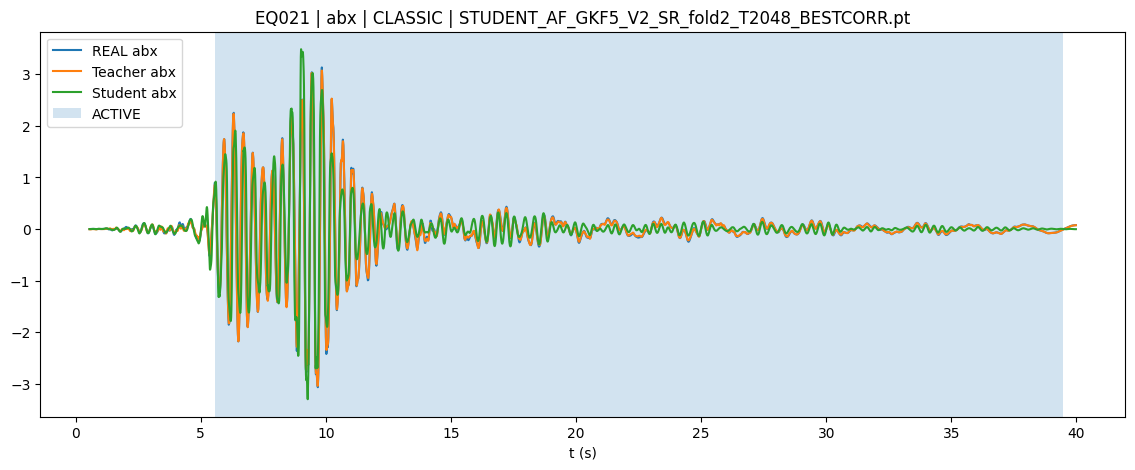

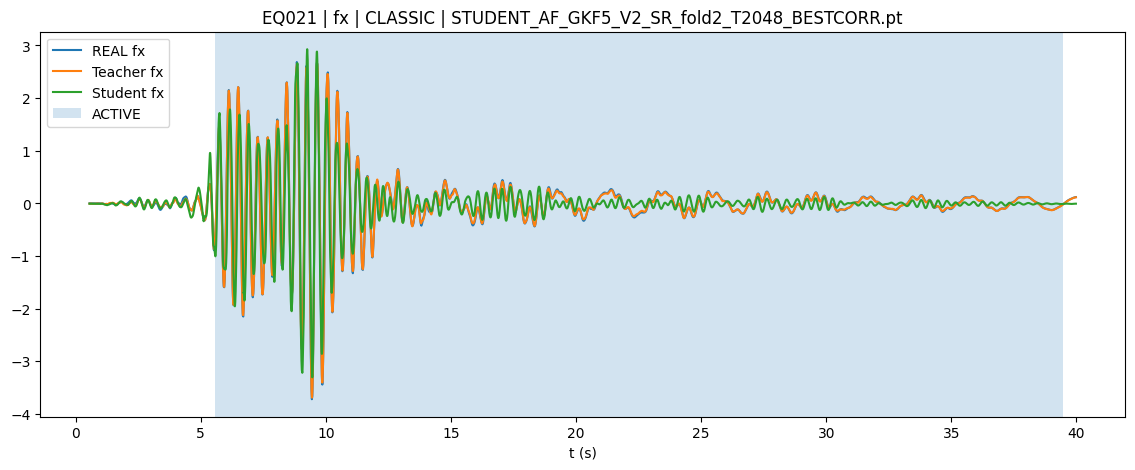

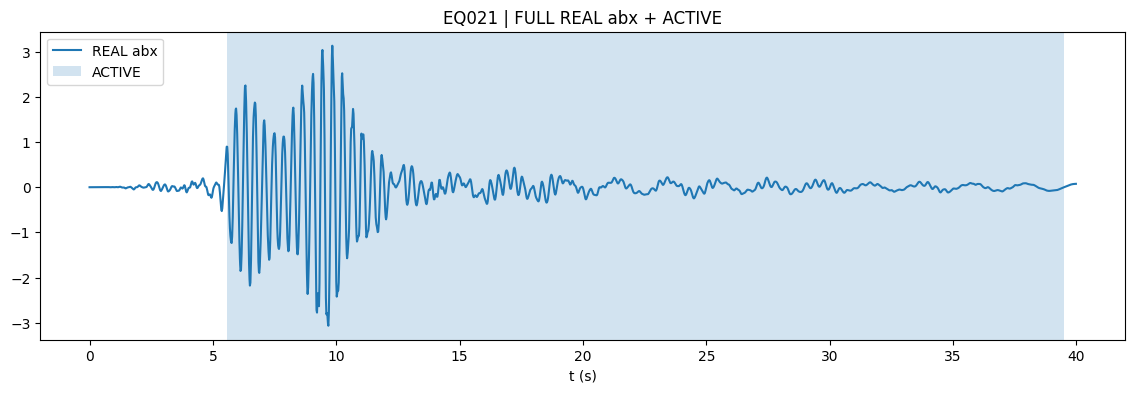

In [ ]:
# =========================================
# A13_AF_DIAG_ACTIVE_EVENTóstico ACTIVE / alignment / teacher vs student ✅
#   - Útil para revisar si el problema de A11 viene de la ventana ACTIVE
#   - Funciona con ckpt clásico o stateful
#   - Grafica:
#       1) abx REAL / Teacher / Student + ACTIVE
#       2) fx  REAL / Teacher / Student + ACTIVE
#   - Imprime métricas:
#       - full
#       - ACTIVE
#       - pre-ACTIVE
#       - post-ACTIVE
# =========================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from types import SimpleNamespace

# ----------------------------
# CONFIG
# ----------------------------
TARGET_RID = str(globals().get("TARGET_RID", "EQ021"))   # cambia aquí el evento a revisar
USE_FROZEN = bool(globals().get("USE_FROZEN_DIAG", True))

# si no quieres usar FROZEN_CKPT_PATH, puedes fijar uno manualmente:
MANUAL_CKPT = globals().get("MANUAL_CKPT_DIAG", None)

_teacher_stride_raw = globals().get("TEACHER_STRIDE_FREEZE", None)
TEACHER_STRIDE = int(_teacher_stride_raw) if _teacher_stride_raw not in [None, "None"] else 4

# para predictor clásico (overlap)
EVAL_STRIDE_DIAG = int(globals().get("EVAL_STRIDE_DIAG", 64))

# opcional: ampliar la vista alrededor del ACTIVE
PAD_SEC_BEFORE = float(globals().get("PAD_SEC_BEFORE", 5.0))
PAD_SEC_AFTER  = float(globals().get("PAD_SEC_AFTER", 5.0))

# ----------------------------
# REQUISITOS
# ----------------------------
assert "resample_to_dtref" in globals(), "Falta resample_to_dtref."
assert "normalize_phys_to_teacher" in globals(), "Falta normalize_phys_to_teacher."
assert "find_active_strict" in globals(), "Falta find_active_strict."
assert "teacher_predict_event_full_teacher_space" in globals(), "Falta teacher_predict_event_full_teacher_space."
assert "load_event_npz" in globals(), "Falta load_event_npz."
assert "SeqStudent" in globals(), "Falta SeqStudent."
assert "DT_REF" in globals(), "Falta DT_REF."
assert "device" in globals(), "Falta device."
assert "STUDENT_IN_IDXS" in globals(), "Falta STUDENT_IN_IDXS."

# necesitamos una lista de archivos candidata
ALL_FILES = []
if "VAL_DIAG_FILES" in globals() and globals()["VAL_DIAG_FILES"] is not None and len(globals()["VAL_DIAG_FILES"]) > 0:
    ALL_FILES += list(globals()["VAL_DIAG_FILES"])
if "OOD_FILES" in globals() and globals()["OOD_FILES"] is not None:
    ALL_FILES += list(globals()["OOD_FILES"])
if "train_files" in globals() and globals()["train_files"] is not None:
    ALL_FILES += list(globals()["train_files"])
if "val_files" in globals() and globals()["val_files"] is not None:
    ALL_FILES += list(globals()["val_files"])

assert len(ALL_FILES) > 0, "No encuentro archivos para buscar TARGET_RID."

# ----------------------------
# HELPERS
# ----------------------------
def _load_npz_any(f):
    out = load_event_npz(f)
    a,b,c,d = out
    if isinstance(a, str) and isinstance(b, np.ndarray):
        rid, X, Y, dt = a, b, c, float(d)
        return X, Y, dt, str(rid)
    X, Y, dt, rid = a, b, float(c), str(d)
    return X, Y, dt, str(rid)

def _infer_arch_from_sd(sd: dict):
    wih0 = sd["lstm.weight_ih_l0"]
    whh0 = sd["lstm.weight_hh_l0"]
    in_dim = int(wih0.shape[1])
    hid    = int(whh0.shape[1])
    layers = 0
    while f"lstm.weight_ih_l{layers}" in sd:
        layers += 1
    return in_dim, hid, layers

def _scalerX_from_cfg(cfg: dict):
    xm   = np.array(cfg.get("scaler_xm", None), dtype=np.float32)
    xp99 = np.array(cfg.get("scaler_xp99", None), dtype=np.float32)
    assert xm is not None and xp99 is not None and xm.size > 0 and xp99.size > 0, \
        "cfg no trae scaler_xm / scaler_xp99."
    eps    = float(cfg.get("scaler_eps", 1e-8))
    clip_x = float(cfg.get("scaler_clip_x", 10.0))
    return SimpleNamespace(xm=xm, xp99=xp99, eps=eps, clip_x=clip_x)

def _normalize_X_only(Xr: np.ndarray, scalerX):
    Xr = np.asarray(Xr, np.float32)
    Xn = (Xr - scalerX.xm) / (scalerX.xp99 + scalerX.eps)
    Xn = np.clip(Xn, -float(scalerX.clip_x), float(scalerX.clip_x))
    return Xn.astype(np.float32)

def metrics_1ch(y_pred, y_true, eps=1e-12):
    a = np.asarray(y_true, np.float64)
    b = np.asarray(y_pred, np.float64)
    if len(a) == 0:
        return dict(rmse=np.nan, corr=np.nan, bias=np.nan, std_ratio=np.nan, rmax=np.nan)
    rmse = float(np.sqrt(np.mean((b-a)**2)))
    bias = float(np.mean(b-a))
    da = a - a.mean()
    db = b - b.mean()
    corr = float((da*db).sum() / (np.sqrt((da*da).sum())*np.sqrt((db*db).sum()) + eps))
    sr = float(b.std() / (a.std() + eps))
    rmax = float((np.max(np.abs(b)) + eps) / (np.max(np.abs(a)) + eps))
    return dict(rmse=rmse, corr=corr, bias=bias, std_ratio=sr, rmax=rmax)

def print_block_metrics(name, yS, yT):
    m_abx = metrics_1ch(yS[:,0], yT[:,0])
    m_fx  = metrics_1ch(yS[:,1], yT[:,1])
    print(f"\n[{name}]")
    print("  abx:", {k: round(v, 4) if np.isfinite(v) else v for k,v in m_abx.items()})
    print("  fx :", {k: round(v, 4) if np.isfinite(v) else v for k,v in m_fx.items()})

def detach_hc(hc):
    if hc is None:
        return None
    h, c = hc
    return (h.detach(), c.detach())

def predict_classic(student_model, Xr_full: np.ndarray, scalerX, T_BACK_local: int, stride_eval: int):
    student_model.eval().to(device)

    Xn_full = _normalize_X_only(Xr_full, scalerX)
    Xs = Xn_full[:, STUDENT_IN_IDXS].astype(np.float32)
    NT = int(Xs.shape[0])

    y_sum = np.zeros((NT, 2), dtype=np.float32)
    y_cnt = np.zeros((NT, 1), dtype=np.float32)

    last0 = max(0, NT - T_BACK_local)
    t0s = list(range(0, max(1, NT - T_BACK_local + 1), stride_eval))
    if len(t0s) == 0 or t0s[-1] != last0:
        t0s.append(last0)

    for t0 in t0s:
        win = Xs[t0:t0+T_BACK_local, :]
        if win.shape[0] < T_BACK_local:
            pad = np.repeat(win[-1:, :], T_BACK_local - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None, :, :]).to(device=device, dtype=torch.float32)
        yh = student_model(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)

        t1 = min(NT, t0 + T_BACK_local)
        y_sum[t0:t1, :] += yh[:(t1 - t0), :]
        y_cnt[t0:t1, :] += 1.0

    y_cnt[y_cnt == 0] = 1.0
    return np.nan_to_num(y_sum / y_cnt, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

def predict_stateful(student_model, Xr_full: np.ndarray, scalerX, chunk_len: int):
    student_model.eval().to(device)

    Xn_full = _normalize_X_only(Xr_full, scalerX)
    Xs = Xn_full[:, STUDENT_IN_IDXS].astype(np.float32)
    NT = int(Xs.shape[0])

    preds = []
    hc = None
    for t0 in range(0, NT, chunk_len):
        xb = torch.from_numpy(Xs[t0:t0+chunk_len][None, :, :]).to(device=device, dtype=torch.float32)
        y, hc = student_model.lstm(xb, hc)
        y = student_model.head(y)
        hc = detach_hc(hc)
        preds.append(y.squeeze(0).detach().cpu().numpy().astype(np.float32))

    return np.concatenate(preds, axis=0)

# ----------------------------
# localizar evento
# ----------------------------
target_file = None
for f in ALL_FILES:
    try:
        _, _, _, rid = _load_npz_any(f)
        if rid == TARGET_RID:
            target_file = f
            break
    except Exception:
        pass

assert target_file is not None, f"No encontré TARGET_RID={TARGET_RID} en archivos conocidos."

# ----------------------------
# ckpt
# ----------------------------
if USE_FROZEN:
    assert "FROZEN_CKPT_PATH" in globals(), "No existe FROZEN_CKPT_PATH."
    CKPT_PATH = str(globals()["FROZEN_CKPT_PATH"])
else:
    assert MANUAL_CKPT is not None, "Define MANUAL_CKPT_DIAG o usa USE_FROZEN_DIAG=True."
    CKPT_PATH = str(MANUAL_CKPT)

ck = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
cfg = ck.get("cfg", {})
sd = ck["state_dict"]

in_dim, hid, layers = _infer_arch_from_sd(sd)
dropout = float(cfg.get("dropout", 0.0))
model = SeqStudent(in_dim=in_dim, hid=hid, layers=layers, dropout=dropout, out_dim=2).to(device)
model.load_state_dict(sd, strict=True)
model.eval()

scalerX = _scalerX_from_cfg(cfg)

is_stateful = ("stateful_chunk_len" in cfg) or ("teacher_stride_stateful" in cfg) or ("STATEFUL" in Path(CKPT_PATH).name.upper())
if is_stateful:
    T_LOCAL = int(cfg.get("stateful_chunk_len", cfg.get("T_BACK", 512)))
else:
    T_LOCAL = int(cfg.get("T_BACK", globals().get("T_BACK", 1024)))

print("[A11_DIAG] TARGET_RID =", TARGET_RID)
print("[A11_DIAG] CKPT =", Path(CKPT_PATH).name)
print("[A11_DIAG] TYPE =", "STATEFUL" if is_stateful else "CLASSIC")
print("[A11_DIAG] T_LOCAL =", T_LOCAL)
print("[A11_DIAG] TEACHER_STRIDE =", TEACHER_STRIDE)
print("[A11_DIAG] EVAL_STRIDE_DIAG =", EVAL_STRIDE_DIAG)

# ----------------------------
# cargar evento + señales
# ----------------------------
X, Y, dt, rid = _load_npz_any(target_file)
Xr, Yr = resample_to_dtref(X, Y, dt, DT_REF)

yTrueN = normalize_phys_to_teacher(Yr).astype(np.float32)  # [abx_true, fx_true, mz_true]
abx_true = yTrueN[:,0]
fx_true  = yTrueN[:,1]

# ACTIVE definido como en A11
_, i0, i1 = find_active_strict(yTrueN[:, 0], DT_REF)

# teacher
yT = teacher_predict_event_full_teacher_space(Xr, stride=TEACHER_STRIDE)
yT = yT if yT.ndim == 2 else yT[:, None]
yT_AF = yT[:, [0,1]].astype(np.float32)

# student
if is_stateful:
    yS = predict_stateful(model, Xr, scalerX, chunk_len=T_LOCAL)
else:
    yS = predict_classic(model, Xr, scalerX, T_BACK_local=T_LOCAL, stride_eval=EVAL_STRIDE_DIAG)

assert yS.shape[0] == yT_AF.shape[0] == yTrueN.shape[0], "Desalineación de longitudes."

# ----------------------------
# bloques para métricas
# ----------------------------
NT = len(abx_true)
pre_slice  = slice(0, i0)
act_slice  = slice(i0, i1)
post_slice = slice(i1, NT)

print(f"[A11_DIAG] NT={NT} | ACTIVE=({i0},{i1}) | t=({i0*DT_REF:.2f}s, {i1*DT_REF:.2f}s) | dur={(i1-i0)*DT_REF:.2f}s")

print_block_metrics("FULL",      yS,            yT_AF)
print_block_metrics("PRE_ACTIVE", yS[pre_slice], yT_AF[pre_slice])
print_block_metrics("ACTIVE",     yS[act_slice], yT_AF[act_slice])
print_block_metrics("POST_ACTIVE",yS[post_slice],yT_AF[post_slice])

# también comparar teacher vs real para entender si ACTIVE con real y teacher están alineados
print("\n[Teacher vs REAL in ACTIVE]")
print("  abx:", {k: round(v, 4) if np.isfinite(v) else v for k,v in metrics_1ch(yT_AF[act_slice,0], abx_true[act_slice]).items()})
print("  fx :", {k: round(v, 4) if np.isfinite(v) else v for k,v in metrics_1ch(yT_AF[act_slice,1], fx_true[act_slice]).items()})

# ----------------------------
# ventana de visualización
# ----------------------------
pad0 = int(PAD_SEC_BEFORE / DT_REF)
pad1 = int(PAD_SEC_AFTER  / DT_REF)

j0 = max(0, i0 - pad0)
j1 = min(NT, i1 + pad1)

t = np.arange(NT) * DT_REF

# ----------------------------
# plots
# ----------------------------
plt.figure(figsize=(14,5))
plt.plot(t[j0:j1], abx_true[j0:j1], label="REAL abx")
plt.plot(t[j0:j1], yT_AF[j0:j1,0], label="Teacher abx")
plt.plot(t[j0:j1], yS[j0:j1,0], label="Student abx")
plt.axvspan(i0*DT_REF, i1*DT_REF, alpha=0.20, label="ACTIVE")
plt.title(f"{TARGET_RID} | abx | {'STATEFUL' if is_stateful else 'CLASSIC'} | {Path(CKPT_PATH).name}")
plt.xlabel("t (s)")
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(t[j0:j1], fx_true[j0:j1], label="REAL fx")
plt.plot(t[j0:j1], yT_AF[j0:j1,1], label="Teacher fx")
plt.plot(t[j0:j1], yS[j0:j1,1], label="Student fx")
plt.axvspan(i0*DT_REF, i1*DT_REF, alpha=0.20, label="ACTIVE")
plt.title(f"{TARGET_RID} | fx | {'STATEFUL' if is_stateful else 'CLASSIC'} | {Path(CKPT_PATH).name}")
plt.xlabel("t (s)")
plt.legend()
plt.show()

# plot full abx para ver si ACTIVE quedó raro
plt.figure(figsize=(14,4))
plt.plot(t, abx_true, label="REAL abx")
plt.axvspan(i0*DT_REF, i1*DT_REF, alpha=0.20, label="ACTIVE")
plt.title(f"{TARGET_RID} | FULL REAL abx + ACTIVE")
plt.xlabel("t (s)")
plt.legend()
plt.show()

## 9. Entrenamiento final de `Mz` con inputs reales

In [ ]:
# =========================================
# A14_MZ_TRUE_ONLY_FINAL
#   - Inputs: [vgN, agN, abxTRUE, fxTRUE]
#   - Target: MzTRUE
#   - Purpose: Upper-bound / sanity check
#   - Guarda history real para Bloque 4
#   - Ahora también guarda train_corr y val_corr
# =========================================
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from types import SimpleNamespace
import pandas as pd

# ---------- CONFIG ----------
RUN_TAG = "STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE"
LR = 3e-4
MAX_EPOCHS = 120
PATIENCE = 12
BATCH_SIZE = 16
STRIDE = 16
NOISE_STD = 0.00

SUMMARY_MAX_EVENTS = 16
SUMMARY_STRIDE = STRIDE
SUMMARY_SAMPLE_POINTS = 20000

SAVE_DIR = Path("/content/memoria/runs_colab/runs_notebook_A_student")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
BESTLOSS_PATH = SAVE_DIR / f"{RUN_TAG}_BESTLOSS.pt"
BESTCORR_PATH = SAVE_DIR / f"{RUN_TAG}_BESTCORR.pt"

assert "train_files" in globals() and "val_files" in globals()
assert "DT_REF" in globals() and "T_BACK" in globals()
assert "device" in globals()
assert "SeqStudent" in globals()
assert "transform_XY" in globals()
assert "normalize_phys_to_teacher" in globals()
assert "find_active_strict" in globals()
assert "resample_to_dtref" in globals()
assert "load_event_npz" in globals()

# ---------- METRICS ----------
def corr_1d(a, b, eps=1e-12):
    a = np.asarray(a, np.float64)
    b = np.asarray(b, np.float64)
    da = a - a.mean()
    db = b - b.mean()
    return float((da * db).sum() / (np.sqrt((da * da).sum()) * np.sqrt((db * db).sum()) + eps))

def metrics_1d(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, np.float64)
    y_pred = np.asarray(y_pred, np.float64)
    err = y_pred - y_true

    rmse = float(np.sqrt(np.mean(err**2)))
    mae  = float(np.mean(np.abs(err)))
    bias = float(np.mean(err))
    corr = corr_1d(y_true, y_pred, eps=eps)

    std_ratio = float(y_pred.std() / (y_true.std() + eps))
    rmax = float((np.max(np.abs(y_pred)) + eps) / (np.max(np.abs(y_true)) + eps))

    denom = float(np.percentile(np.abs(y_true), 95) + eps)
    nrmse_p95 = float(rmse / denom)

    return {
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "corr": corr,
        "std_ratio": std_ratio,
        "rmax": rmax,
        "nrmse_p95": nrmse_p95
    }

# ---------- UTILS ----------
def _infer_arch_from_sd(sd: dict):
    wih0 = sd["lstm.weight_ih_l0"]
    whh0 = sd["lstm.weight_hh_l0"]
    in_dim = int(wih0.shape[1])
    hid    = int(whh0.shape[1])
    layers = 0
    while f"lstm.weight_ih_l{layers}" in sd:
        layers += 1
    return in_dim, hid, layers

def _scaler_from_cfg(cfg: dict):
    xm   = np.array(cfg["scaler_xm"], dtype=np.float32)
    xp99 = np.array(cfg["scaler_xp99"], dtype=np.float32)

    ym   = np.array(cfg.get("scaler_ym", [0.0, 0.0, 0.0]), dtype=np.float32)
    yp99 = np.array(cfg.get("scaler_yp99", [1.0, 1.0, 1.0]), dtype=np.float32)

    sc = SimpleNamespace(
        xm=xm,
        xp99=xp99,
        ym=ym,
        yp99=yp99,
        eps=float(cfg.get("scaler_eps", 1e-8)),
        clip_x=float(cfg.get("scaler_clip_x", 10.0)),
        clip_y=float(cfg.get("scaler_clip_y", 10.0)),
        pctl=int(cfg.get("scaler_pctl", 99))
    )
    return sc

def _load_npz_any(f):
    out = load_event_npz(f)
    a, b, c, d = out
    if isinstance(a, str) and isinstance(b, np.ndarray):
        rid, X, Y, dt = a, b, c, float(d)
        return X, Y, dt, str(rid)
    X, Y, dt, rid = a, b, float(c), str(d)
    return X, Y, dt, str(rid)

def make_windows_true_only(f, scalerX, stride=16):
    X, Y, dt, rid = _load_npz_any(f)
    Xr, Yr = resample_to_dtref(X, Y, dt, DT_REF)

    yTrueN = normalize_phys_to_teacher(Yr).astype(np.float32)
    _, i0, i1 = find_active_strict(yTrueN[:, 0], DT_REF)

    Xn_full, _ = transform_XY(
        np.asarray(Xr, np.float32),
        np.zeros((Xr.shape[0], 3), np.float32),
        scalerX
    )
    vgagN = Xn_full[:, [0, 1]].astype(np.float32)

    AF_true = yTrueN[:, [0, 1]].astype(np.float32)
    Mz_true = yTrueN[:, 2].astype(np.float32)

    Z_true = np.concatenate([vgagN, AF_true], axis=1).astype(np.float32)

    items = []
    for t0 in range(i0, max(i0 + 1, i1 - T_BACK + 1), stride):
        xw = Z_true[t0:t0 + T_BACK, :]
        yw = Mz_true[t0:t0 + T_BACK]
        if xw.shape[0] < T_BACK:
            break
        items.append((xw, yw[:, None], rid))
    return items

def iter_minibatches(items, bs):
    idx = np.arange(len(items))
    np.random.shuffle(idx)
    for k in range(0, len(idx), bs):
        sel = idx[k:k + bs]
        x = np.stack([items[i][0] for i in sel], axis=0)
        y = np.stack([items[i][1] for i in sel], axis=0)
        yield x, y

@torch.no_grad()
def eval_epoch_true(files, model_MZ, scalerX, stride=16):
    model_MZ.eval()
    losses, corrs = [], []
    loss_fn = nn.MSELoss()

    for f in files:
        items = make_windows_true_only(f, scalerX, stride=stride)
        if len(items) == 0:
            continue

        ypred_all, ytrue_all = [], []
        lsum, nsum = 0.0, 0

        for k in range(0, len(items), BATCH_SIZE):
            batch = items[k:k + BATCH_SIZE]
            xb = np.stack([bb[0] for bb in batch], axis=0)
            yb = np.stack([bb[1] for bb in batch], axis=0)

            if NOISE_STD > 0:
                xb = xb + (NOISE_STD * np.random.randn(*xb.shape)).astype(np.float32)

            xb_t = torch.from_numpy(xb).float().to(device)
            yb_t = torch.from_numpy(yb).float().to(device)

            yh = model_MZ(xb_t)
            l = float(loss_fn(yh, yb_t).item())
            lsum += l * xb.shape[0]
            nsum += xb.shape[0]

            ypred_all.append(yh.detach().cpu().numpy().reshape(-1))
            ytrue_all.append(yb.reshape(-1))

        losses.append(lsum / max(1, nsum))
        ypred_all = np.concatenate(ypred_all)
        ytrue_all = np.concatenate(ytrue_all)
        corrs.append(corr_1d(ytrue_all, ypred_all))

    return float(np.mean(losses)), float(np.mean(corrs))

@torch.no_grad()
def summarize_val(files, model_MZ, scalerX, stride=16, max_events=12, max_points=20000):
    model_MZ.eval()
    rows = []
    agg_true = []
    agg_pred = []

    for f in files:
        items = make_windows_true_only(f, scalerX, stride=stride)
        if len(items) == 0:
            continue

        ypred_all, ytrue_all = [], []
        for k in range(0, len(items), BATCH_SIZE):
            batch = items[k:k + BATCH_SIZE]
            xb = np.stack([bb[0] for bb in batch], axis=0)
            yb = np.stack([bb[1] for bb in batch], axis=0)

            xb_t = torch.from_numpy(xb).float().to(device)
            yh = model_MZ(xb_t).detach().cpu().numpy()

            ypred_all.append(yh.reshape(-1))
            ytrue_all.append(yb.reshape(-1))

        ypred_all = np.concatenate(ypred_all)
        ytrue_all = np.concatenate(ytrue_all)

        rid = items[0][2] if len(items[0]) >= 3 else "UNK"
        m = metrics_1d(ytrue_all, ypred_all)

        rows.append((rid, len(items), m))
        if len(agg_true) < max_points:
            take = min(max_points - len(agg_true), ytrue_all.size)
            agg_true.append(ytrue_all[:take])
            agg_pred.append(ypred_all[:take])

    rows.sort(key=lambda x: x[2]["corr"])

    print("\n================ SUMMARY (VAL | TRUE-only inference) ================")
    if len(rows) == 0:
        print("No rows to summarize.")
        return

    print(f"{'RID':>6s} | {'nWin':>4s} | {'corr':>6s} | {'rmse':>7s} | {'bias':>7s} | {'sr':>6s} | {'rmax':>6s} | {'nrmse95':>8s}")
    print("-" * 86)

    for rid, nwin, m in rows[:max_events]:
        print(
            f"{rid:>6s} | {nwin:4d} | {m['corr']:6.3f} | {m['rmse']:7.4f} | {m['bias']:7.4f} | "
            f"{m['std_ratio']:6.3f} | {m['rmax']:6.3f} | {m['nrmse_p95']:8.3f}"
        )

    yT = np.concatenate(agg_true) if len(agg_true) else None
    yP = np.concatenate(agg_pred) if len(agg_pred) else None
    if yT is not None and yT.size > 0:
        mg = metrics_1d(yT, yP)
        print("\n---------------- GLOBAL (capped points) ----------------")
        print("global:", mg)

# ---------- Load AF ckpt ----------
CKPT_AF = None
if "FROZEN_CKPT_PATH" in globals():
    CKPT_AF = str(FROZEN_CKPT_PATH)
elif "FREEZE_CKPT_PATH" in globals():
    CKPT_AF = str(FREEZE_CKPT_PATH)
elif "best_path_AF" in globals():
    CKPT_AF = str(best_path_AF)
else:
    raise AssertionError("No encuentro CKPT AF.")

ck_af = torch.load(CKPT_AF, map_location="cpu", weights_only=False)
sd_af = ck_af["state_dict"]
cfg_af = ck_af.get("cfg", {})
scalerX = _scaler_from_cfg(cfg_af)

_, hid, layers = _infer_arch_from_sd(sd_af)
DROPOUT = float(globals().get("STUDENT_DROPOUT", 0.1))

print("[A13_TRUE_ONLY_MZ] AF ckpt:", Path(CKPT_AF).name)
print("[A13_TRUE_ONLY_MZ] scalerX:", "xm", scalerX.xm.shape, "| xp99", scalerX.xp99.shape, "| eps", scalerX.eps)
print("[A13_TRUE_ONLY_MZ] model_MZ arch:", f"in_dim=4 hid={hid} layers={layers} dropout={DROPOUT}")

# ---------- Build MZ model ----------
model_MZ = SeqStudent(in_dim=4, hid=hid, layers=layers, dropout=DROPOUT, out_dim=1).to(device)
opt = torch.optim.AdamW(model_MZ.parameters(), lr=LR)
loss_fn = nn.MSELoss()

best_loss = 1e18
best_corr = -1e18
pat = 0

# ---------- HISTORY ----------
history_mz = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_corr": [],
    "val_corr": [],
}

# ---------- TRAIN ----------
for ep in range(1, MAX_EPOCHS + 1):
    model_MZ.train()
    tr_losses = []
    tr_corrs = []

    for f in train_files:
        items = make_windows_true_only(f, scalerX, stride=STRIDE)
        if len(items) == 0:
            continue

        for xb, yb in iter_minibatches(items, BATCH_SIZE):
            if NOISE_STD > 0:
                xb = xb + (NOISE_STD * np.random.randn(*xb.shape)).astype(np.float32)

            xb_t = torch.from_numpy(xb).float().to(device)
            yb_t = torch.from_numpy(yb).float().to(device)

            opt.zero_grad(set_to_none=True)
            yh = model_MZ(xb_t)
            loss = loss_fn(yh, yb_t)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_MZ.parameters(), 1.0)
            opt.step()

            tr_losses.append(float(loss.item()))
            tr_corrs.append(corr_1d(
                yb_t.detach().cpu().numpy().reshape(-1),
                yh.detach().cpu().numpy().reshape(-1)
            ))

    va_loss, va_corr = eval_epoch_true(val_files, model_MZ, scalerX, stride=STRIDE)
    tr_loss = float(np.mean(tr_losses)) if len(tr_losses) else 999.0
    tr_corr = float(np.mean(tr_corrs)) if len(tr_corrs) else float("nan")

    history_mz["epoch"].append(ep)
    history_mz["train_loss"].append(tr_loss)
    history_mz["val_loss"].append(va_loss)
    history_mz["train_corr"].append(tr_corr)
    history_mz["val_corr"].append(va_corr)

    print(
        f"[{RUN_TAG}] ep {ep:03d} | "
        f"tr {tr_loss:.5f} | va {va_loss:.5f} | "
        f"tr_corr {tr_corr:.3f} | va_corr {va_corr:.3f}",
        flush=True
    )

    improved = False
    if va_loss < best_loss - 1e-6:
        best_loss = va_loss
        improved = True
        torch.save(
            {"state_dict": model_MZ.state_dict(),
             "cfg": {"run": RUN_TAG, "lr": LR, "stride": STRIDE,
                     "inputs": "[vgN,agN,abxTRUE,fxTRUE]", "target": "MzTRUE", "upper_bound": True}},
            BESTLOSS_PATH
        )

    if va_corr > best_corr + 1e-6:
        best_corr = va_corr
        improved = True
        torch.save(
            {"state_dict": model_MZ.state_dict(),
             "cfg": {"run": RUN_TAG, "lr": LR, "stride": STRIDE,
                     "inputs": "[vgN,agN,abxTRUE,fxTRUE]", "target": "MzTRUE", "upper_bound": True}},
            BESTCORR_PATH
        )

    if improved:
        pat = 0
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f"[{RUN_TAG}] Early stopping.")
            break

print("\nSaved BESTLOSS:", str(BESTLOSS_PATH))
print("Saved BESTCORR:", str(BESTCORR_PATH))
print("best_loss:", best_loss, "| best_corr:", best_corr)

# ---------- save history ----------
HIST_MZ_NPZ = SAVE_DIR / f"{RUN_TAG}_history.npz"
HIST_MZ_CSV = SAVE_DIR / f"{RUN_TAG}_history.csv"

np.savez(
    HIST_MZ_NPZ,
    epoch=np.array(history_mz["epoch"], dtype=np.int32),
    train_loss=np.array(history_mz["train_loss"], dtype=np.float32),
    val_loss=np.array(history_mz["val_loss"], dtype=np.float32),
    train_corr=np.array(history_mz["train_corr"], dtype=np.float32),
    val_corr=np.array(history_mz["val_corr"], dtype=np.float32),
)

pd.DataFrame(history_mz).to_csv(HIST_MZ_CSV, index=False)

print("✅ History NPZ guardado:", HIST_MZ_NPZ)
print("✅ History CSV guardado:", HIST_MZ_CSV)

# ---------- SUMMARY (end) ----------
print("\n================ FINAL SUMMARY ON VAL ================")
summarize_val(
    val_files,
    model_MZ,
    scalerX,
    stride=SUMMARY_STRIDE,
    max_events=int(SUMMARY_MAX_EVENTS),
    max_points=int(SUMMARY_SAMPLE_POINTS)
)

[A13_TRUE_ONLY_MZ] AF ckpt: STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt
[A13_TRUE_ONLY_MZ] scalerX: xm (5,) | xp99 (5,) | eps 1e-08
[A13_TRUE_ONLY_MZ] model_MZ arch: in_dim=4 hid=128 layers=2 dropout=0.1
[STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE] ep 001 | tr 0.00201 | va 0.00226 | tr_corr 0.868 | va_corr 0.966
[STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE] ep 002 | tr 0.00153 | va 0.00192 | tr_corr 0.915 | va_corr 0.984
[STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE] ep 003 | tr 0.00088 | va 0.00158 | tr_corr 0.948 | va_corr 0.986
[STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE] ep 004 | tr 0.00074 | va 0.00108 | tr_corr 0.957 | va_corr 0.989
[STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE] ep 005 | tr 0.00064 | va 0.00100 | tr_corr 0.963 | va_corr 0.990
[STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE] ep 006 | tr 0.00062 | va 0.00104 | tr_corr 0.966 | va_corr 0.990
[STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE] ep 007 | tr 0.00056 | va 0.00092 | tr_corr 0.968 | va_corr 0.990
[STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE] ep 008 | tr 0.00052

In [ ]:
import torch, pprint

CKPT_MZ = str(BESTCORR_PATH)   # o BESTLOSS_PATH, si ese usarás en Resultados
ck_mz = torch.load(CKPT_MZ, map_location="cpu", weights_only=False)

print("CKPT_MZ:", CKPT_MZ)
print("keys:", ck_mz.keys())
print("cfg keys:", list(ck_mz.get("cfg", {}).keys()))
print("\nCFG MZ:")
pprint.pp(ck_mz.get("cfg", {}))

CKPT_MZ: /content/memoria/runs_colab/runs_notebook_A_student/STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_BESTCORR.pt
keys: dict_keys(['state_dict', 'cfg'])
cfg keys: ['run', 'lr', 'stride', 'inputs', 'target', 'upper_bound']

CFG MZ:
{'run': 'STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE',
 'lr': 0.0003,
 'stride': 16,
 'inputs': '[vgN,agN,abxTRUE,fxTRUE]',
 'target': 'MzTRUE',
 'upper_bound': True}


In [ ]:
print("OOD_RIDS:", OOD_RIDS if "OOD_RIDS" in globals() else "NA")
print("len(OOD_FILES):", len(OOD_FILES) if "OOD_FILES" in globals() else "NA")
if "OOD_FILES" in globals():
    for p in OOD_FILES:
        print(" -", p)

OOD_RIDS: ['EQ007', 'EQ019', 'EQ052', 'EQ081']
len(OOD_FILES): 4
 - /content/memoria/processed_step_full_v2/EQ007.npz
 - /content/memoria/processed_step_full_v2/EQ019.npz
 - /content/memoria/processed_step_full_v2/EQ052.npz
 - /content/memoria/processed_step_full_v2/EQ081.npz


## 10. Experimento complementario `AF → Mz`

In [ ]:
# =========================================
# A15_MZ_HAT_FINETUNE_EXPERIMENTÓN)
#   - Separa T_BACK_AF (del ckpt AF) y T_BACK_MZ (del ckpt MZ o global)
#   - AF_hat usa scalerX del fold congelado (cfg_af)
#   - CALIBRACIÓN DESACTIVADA: usa AF RAW
# =========================================
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from types import SimpleNamespace

# ---------- CONFIG ----------
RUN_TAG = "STUDENT_MZ_FINETUNE_TRUEONLY_onHAT_physloss_v2_RAW"
LR = 1e-4
MAX_EPOCHS = 80
PATIENCE = 12
BATCH_SIZE = 16

STRIDE = 16
NOISE_STD = 0.005
LAMBDA_BETA = (2.0, 6.0)

P_TRUE_ABX_START = 0.60
P_TRUE_ABX_END   = 0.10
P_TRUE_FX_START  = 0.85
P_TRUE_FX_END    = 0.20

FINETUNE_LAST_HAT_EPOCHS = 15

LAMBDA_E = 1.00
LAMBDA_S = 0.30
HUBER_DELTA = None  # e.g. 1.0 si quieres SmoothL1

SAVE_DIR = Path("/content/memoria/runs_colab/runs_notebook_A_student")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
BESTLOSS_PATH = SAVE_DIR / f"{RUN_TAG}_BESTLOSS.pt"
BESTCORR_PATH = SAVE_DIR / f"{RUN_TAG}_BESTCORR.pt"

assert "train_files" in globals() and "val_files" in globals()
assert "DT_REF" in globals()
assert "device" in globals()
assert "SeqStudent" in globals()
assert "normalize_phys_to_teacher" in globals()
assert "find_active_strict" in globals()
assert "resample_to_dtref" in globals()
assert "load_event_npz" in globals()

# ---------- utils ----------
def lin_schedule(ep0, max_ep, p0, p1):
    if max_ep <= 1:
        return float(p1)
    a = ep0 / (max_ep - 1)
    return float((1-a)*p0 + a*p1)

def corr_1d(a, b, eps=1e-12):
    a = np.asarray(a, np.float64); b = np.asarray(b, np.float64)
    da = a - a.mean(); db = b - b.mean()
    return float((da*db).sum() / (np.sqrt((da*da).sum())*np.sqrt((db*db).sum()) + eps))

def _infer_arch_from_sd(sd: dict):
    wih0 = sd["lstm.weight_ih_l0"]
    whh0 = sd["lstm.weight_hh_l0"]
    in_dim = int(wih0.shape[1])
    hid    = int(whh0.shape[1])
    layers = 0
    while f"lstm.weight_ih_l{layers}" in sd:
        layers += 1
    return in_dim, hid, layers

def _scalerX_from_cfg(cfg: dict):
    xm   = np.array(cfg.get("scaler_xm", None), dtype=np.float32) if cfg.get("scaler_xm", None) is not None else None
    xp99 = np.array(cfg.get("scaler_xp99", None), dtype=np.float32) if cfg.get("scaler_xp99", None) is not None else None

    assert xm is not None and xp99 is not None, "cfg_af no trae scaler_xm/xp99 (A9/A10 deberían guardarlo)."

    sc = SimpleNamespace(
        xm=xm, xp99=xp99,
        eps=float(cfg.get("scaler_eps", 1e-8)),
        clip_x=float(cfg.get("scaler_clip_x", float(globals().get("CLIP_X", 10.0)))),
        pctl=int(cfg.get("scaler_pctl", int(globals().get("PCTL", 99))))
    )
    return sc

def _load_npz_any(f):
    out = load_event_npz(f)
    a,b,c,d = out
    if isinstance(a, str) and isinstance(b, np.ndarray):
        rid, X, Y, dt = a, b, c, float(d)
        return X, Y, dt, str(rid)
    X, Y, dt, rid = a, b, float(c), str(d)
    return X, Y, dt, str(rid)

def _normalize_X_only(Xr: np.ndarray, scalerX):
    Xr = np.asarray(Xr, np.float32)
    Xn = (Xr - scalerX.xm) / (scalerX.xp99 + scalerX.eps)
    Xn = np.clip(Xn, -float(scalerX.clip_x), float(scalerX.clip_x))
    return Xn.astype(np.float32)

# ============================================================
# CALIBRACIÓN AF DESACTIVADA
# ============================================================
CALIB_ON = False

def apply_calib_AF(y_af_2ch: np.ndarray):
    """
    SIN CALIBRACIÓN: retorna AF RAW.
    """
    return np.asarray(y_af_2ch, np.float32)

# ---------- AF predict (teacher-space) ----------
@torch.no_grad()
def student_predict_AF_teacher_space(model_AF, Xr, scalerX, T_BACK_AF: int, stride_eval: int):
    model_AF.eval().to(device)
    Xn_full = _normalize_X_only(Xr, scalerX)
    Xs = Xn_full[:, [0,1]].astype(np.float32)  # vgN, agN
    NT = int(Xs.shape[0])

    y_sum = np.zeros((NT, 2), np.float32)
    y_cnt = np.zeros((NT, 1), np.float32)

    last0 = max(0, NT - T_BACK_AF)
    t0s = list(range(0, max(1, NT - T_BACK_AF + 1), stride_eval))
    if len(t0s) == 0 or t0s[-1] != last0:
        t0s.append(last0)

    for t0 in t0s:
        win = Xs[t0:t0+T_BACK_AF, :]
        if win.shape[0] < T_BACK_AF:
            pad = np.repeat(win[-1:, :], T_BACK_AF - win.shape[0], axis=0)
            win = np.concatenate([win, pad], axis=0)

        xb = torch.from_numpy(win[None,:,:]).to(device=device, dtype=torch.float32)
        yh = model_AF(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)  # (T,2)

        t1 = min(NT, t0 + T_BACK_AF)
        y_sum[t0:t1,:] += yh[:(t1-t0),:]
        y_cnt[t0:t1,:] += 1.0

    y_cnt[y_cnt == 0] = 1.0
    y = y_sum / y_cnt
    y = apply_calib_AF(y)  # <- ahora no hace nada, deja RAW
    return np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# ---------- dataset windows ----------
def make_windows_for_event(f, model_AF, scalerX, T_BACK_AF: int, T_BACK_MZ: int, stride=16):
    """
    Items por evento:
      vg: (T_MZ,2) = vgN,agN
      ah: (T_MZ,2) = [abx_hat, fx_hat] teacher-space (RAW)
      at: (T_MZ,2) = [abx_true, fx_true] teacher-space
      y : (T_MZ,1) = Mz_true teacher-space
    """
    X, Y, dt, rid = _load_npz_any(f)
    Xr, Yr = resample_to_dtref(X, Y, dt, DT_REF)

    yTrueN = normalize_phys_to_teacher(Yr).astype(np.float32)   # (NT,3): [abx, fx, Mz]
    _, i0, i1 = find_active_strict(yTrueN[:,0], DT_REF)

    Xn_full = _normalize_X_only(Xr, scalerX)
    vgagN   = Xn_full[:, [0,1]].astype(np.float32)              # (NT,2)

    AF_true = yTrueN[:, [0,1]].astype(np.float32)               # (NT,2)
    Mz_true = yTrueN[:, 2].astype(np.float32)                   # (NT,)

    AF_hat = student_predict_AF_teacher_space(
        model_AF, Xr, scalerX, T_BACK_AF=T_BACK_AF, stride_eval=stride
    )  # (NT,2)

    items = []
    for t0 in range(i0, max(i0+1, i1 - T_BACK_MZ + 1), stride):
        vg = vgagN[t0:t0+T_BACK_MZ, :]
        ah = AF_hat[t0:t0+T_BACK_MZ, :]
        at = AF_true[t0:t0+T_BACK_MZ, :]
        yw = Mz_true[t0:t0+T_BACK_MZ]
        if vg.shape[0] < T_BACK_MZ:
            break
        items.append((vg, ah, at, yw[:,None], rid))
    return items

def iter_minibatches(items, bs):
    idx = np.arange(len(items))
    np.random.shuffle(idx)
    for k in range(0, len(idx), bs):
        sel = idx[k:k+bs]
        vg = np.stack([items[i][0] for i in sel], axis=0)  # (B,T,2)
        ah = np.stack([items[i][1] for i in sel], axis=0)  # (B,T,2)
        at = np.stack([items[i][2] for i in sel], axis=0)  # (B,T,2)
        y  = np.stack([items[i][3] for i in sel], axis=0)  # (B,T,1)
        yield vg, ah, at, y

def metrics_dict(y_true, y_pred, eps=1e-12):
    a = np.asarray(y_true, np.float64)
    b = np.asarray(y_pred, np.float64)
    rmse = float(np.sqrt(np.mean((b-a)**2)))
    mae  = float(np.mean(np.abs(b-a)))
    bias = float(np.mean(b-a))
    da = a - a.mean(); db = b - b.mean()
    corr = float((da*db).sum() / (np.sqrt((da*da).sum())*np.sqrt((db*db).sum()) + eps))
    sr = float(b.std() / (a.std() + eps))
    rmax = float((np.max(np.abs(b)) + eps) / (np.max(np.abs(a)) + eps))
    p95 = float(np.percentile(np.abs(a), 95) + eps)
    nrmse95 = float(rmse / p95)
    energy_ratio = float((np.mean(b*b) + eps) / (np.mean(a*a) + eps))
    return dict(
        rmse=rmse, mae=mae, bias=bias, corr=corr, std_ratio=sr, rmax=rmax,
        nrmse_p95=nrmse95, peak_ratio=rmax, energy_ratio=energy_ratio
    )

@torch.no_grad()
def eval_epoch_hat(files, model_MZ, model_AF, scalerX, T_BACK_AF: int, T_BACK_MZ: int, stride=16):
    model_MZ.eval()
    losses, corrs = [], []
    loss_base = nn.SmoothL1Loss(beta=HUBER_DELTA) if HUBER_DELTA is not None else nn.MSELoss()

    for f in files:
        items = make_windows_for_event(
            f, model_AF, scalerX, T_BACK_AF=T_BACK_AF, T_BACK_MZ=T_BACK_MZ, stride=stride
        )
        if len(items) == 0:
            continue

        ypred_all, ytrue_all = [], []
        lsum, nsum = 0.0, 0

        for k in range(0, len(items), BATCH_SIZE):
            batch = items[k:k+BATCH_SIZE]
            vg = np.stack([bb[0] for bb in batch], axis=0)
            ah = np.stack([bb[1] for bb in batch], axis=0)
            yb = np.stack([bb[3] for bb in batch], axis=0)

            xhat = np.concatenate([vg, ah], axis=2).astype(np.float32)
            xb_t = torch.from_numpy(xhat).float().to(device)
            yb_t = torch.from_numpy(yb).float().to(device)

            yh = model_MZ(xb_t)
            l = loss_base(yh, yb_t).item()
            lsum += l * xhat.shape[0]
            nsum += xhat.shape[0]

            ypred_all.append(yh.detach().cpu().numpy().reshape(-1))
            ytrue_all.append(yb.reshape(-1))

        losses.append(lsum / max(1, nsum))
        ypred_all = np.concatenate(ypred_all)
        ytrue_all = np.concatenate(ytrue_all)
        corrs.append(corr_1d(ytrue_all, ypred_all))

    return float(np.mean(losses)), float(np.mean(corrs))

def final_summary_hat(files, model_MZ, model_AF, scalerX, T_BACK_AF: int, T_BACK_MZ: int, stride=16, cap_points=20000):
    rows = []
    all_t, all_p = [], []

    for f in files:
        X, Y, dt, rid = _load_npz_any(f)
        Xr, Yr = resample_to_dtref(X, Y, dt, DT_REF)
        yTrueN = normalize_phys_to_teacher(Yr).astype(np.float32)
        _, i0, i1 = find_active_strict(yTrueN[:,0], DT_REF)

        Xn_full = _normalize_X_only(Xr, scalerX)
        vgagN = Xn_full[:, [0,1]].astype(np.float32)
        AF_hat = student_predict_AF_teacher_space(
            model_AF, Xr, scalerX, T_BACK_AF=T_BACK_AF, stride_eval=stride
        ).astype(np.float32)

        xhat_full = np.concatenate([vgagN, AF_hat], axis=1).astype(np.float32)  # (NT,4)
        Mz_true = yTrueN[:,2].astype(np.float32)

        NT = xhat_full.shape[0]
        y_sum = np.zeros((NT,1), np.float32)
        y_cnt = np.zeros((NT,1), np.float32)

        last0 = max(0, NT - T_BACK_MZ)
        t0s = list(range(0, max(1, NT - T_BACK_MZ + 1), stride))
        if len(t0s) == 0 or t0s[-1] != last0:
            t0s.append(last0)

        model_MZ.eval().to(device)
        with torch.no_grad():
            for t0 in t0s:
                win = xhat_full[t0:t0+T_BACK_MZ, :]
                if win.shape[0] < T_BACK_MZ:
                    pad = np.repeat(win[-1:, :], T_BACK_MZ - win.shape[0], axis=0)
                    win = np.concatenate([win, pad], axis=0)
                xb = torch.from_numpy(win[None,:,:]).float().to(device)
                yh = model_MZ(xb).squeeze(0).detach().cpu().numpy().astype(np.float32)  # (T,1)
                t1 = min(NT, t0 + T_BACK_MZ)
                y_sum[t0:t1,:] += yh[:(t1-t0),:]
                y_cnt[t0:t1,:] += 1.0

        y_cnt[y_cnt == 0] = 1.0
        Mz_pred = (y_sum / y_cnt).reshape(-1)

        t = Mz_true[i0:i1].reshape(-1)
        p = Mz_pred[i0:i1].reshape(-1)

        md = metrics_dict(t, p)
        rows.append((rid, int(len(t)), md["corr"], md["rmse"], md["bias"], md["std_ratio"],
                     md["rmax"], md["nrmse_p95"], md["peak_ratio"], md["energy_ratio"]))

        if cap_points is not None and cap_points > 0 and len(t) > cap_points:
            idx = np.linspace(0, len(t)-1, cap_points).astype(int)
            t = t[idx]
            p = p[idx]
        all_t.append(t)
        all_p.append(p)

    if len(all_t) == 0:
        return rows, None

    all_t = np.concatenate(all_t)
    all_p = np.concatenate(all_p)
    glob = metrics_dict(all_t, all_p)
    return rows, glob

# ---------- Load AF frozen ckpt + scaler ----------
CKPT_AF = None
if "FROZEN_CKPT_PATH" in globals():
    CKPT_AF = str(FROZEN_CKPT_PATH)
elif "FREEZE_CKPT_PATH" in globals():
    CKPT_AF = str(FREEZE_CKPT_PATH)
elif "best_path_AF" in globals():
    CKPT_AF = str(best_path_AF)
else:
    raise AssertionError("No encuentro CKPT AF (FROZEN_CKPT_PATH/FREEZE_CKPT_PATH/best_path_AF).")

ck_af = torch.load(CKPT_AF, map_location="cpu", weights_only=False)
sd_af = ck_af["state_dict"]
cfg_af = ck_af.get("cfg", {})
scalerX = _scalerX_from_cfg(cfg_af)

_, hid_af, layers_af = _infer_arch_from_sd(sd_af)
DROPOUT_AF = float(cfg_af.get("dropout", 0.0))
T_BACK_AF = int(cfg_af.get("T_BACK", cfg_af.get("T_BACK_AF", 2048)))

print("[A15] AF ckpt:", Path(CKPT_AF).name)
print("[A15] AF arch: in_dim=2 hid=%d layers=%d dropout=%.3f | T_BACK_AF=%d" % (hid_af, layers_af, DROPOUT_AF, T_BACK_AF))
print("[A15] scalerX:", "xm", scalerX.xm.shape, "| xp99", scalerX.xp99.shape, "| eps", scalerX.eps, "| clip_x", scalerX.clip_x)
print("[A15] CALIB_ON:", CALIB_ON, "| AF RAW loaded")

model_AF = SeqStudent(in_dim=2, hid=hid_af, layers=layers_af, dropout=DROPOUT_AF, out_dim=2).to(device)
model_AF.load_state_dict(sd_af, strict=True)
model_AF.eval()

# ---------- Load MZ TRUE-only ckpt as init ----------
CKPT_MZ_INIT = globals().get("BEST_MZ_TRUEONLY_PATH", None)
if CKPT_MZ_INIT is None:
    cand = SAVE_DIR / "STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_BESTLOSS.pt"
    if cand.exists():
        CKPT_MZ_INIT = str(cand)
    else:
        raise AssertionError("No encuentro ckpt init de MZ TRUE-only. Define BEST_MZ_TRUEONLY_PATH o verifica el nombre.")

ck_mz = torch.load(CKPT_MZ_INIT, map_location="cpu", weights_only=False)
sd_mz = ck_mz["state_dict"]
in_dim_mz, hid_mz, layers_mz = _infer_arch_from_sd(sd_mz)

T_BACK_MZ = int(ck_mz.get("cfg", {}).get("T_BACK", globals().get("T_BACK", 1024)))

DROPOUT_MZ = float(globals().get("STUDENT_DROPOUT", 0.1))
model_MZ = SeqStudent(in_dim=4, hid=hid_mz, layers=layers_mz, dropout=DROPOUT_MZ, out_dim=1).to(device)
model_MZ.load_state_dict(sd_mz, strict=True)

print("[A15] MZ init ckpt:", Path(str(CKPT_MZ_INIT)).name)
print("[A15] MZ arch: in_dim=4 hid=%d layers=%d dropout=%.3f | T_BACK_MZ=%d" % (hid_mz, layers_mz, DROPOUT_MZ, T_BACK_MZ))

# ---------- Optim/Loss ----------
opt = torch.optim.AdamW(model_MZ.parameters(), lr=LR, weight_decay=1e-4)
loss_base = nn.SmoothL1Loss(beta=HUBER_DELTA) if HUBER_DELTA is not None else nn.MSELoss()

def phys_loss(yh, yt):
    l_mse = loss_base(yh, yt)

    E_yh = torch.mean(yh*yh, dim=1)
    E_yt = torch.mean(yt*yt, dim=1)
    l_E = torch.mean((E_yh - E_yt)**2)

    std_yh = torch.std(yh, dim=1, unbiased=False)
    std_yt = torch.std(yt, dim=1, unbiased=False)
    l_S = torch.mean((std_yh - std_yt)**2)

    return l_mse + LAMBDA_E * l_E + LAMBDA_S * l_S

best_loss = 1e18
best_corr = -1e18
pat = 0

# ---------- TRAIN ----------
for ep in range(1, MAX_EPOCHS+1):
    model_MZ.train()

    if ep > (MAX_EPOCHS - FINETUNE_LAST_HAT_EPOCHS):
        p_abx = 0.0
        p_fx  = 0.0
        force_lambda0 = True
    else:
        p_abx = lin_schedule(ep-1, MAX_EPOCHS, P_TRUE_ABX_START, P_TRUE_ABX_END)
        p_fx  = lin_schedule(ep-1, MAX_EPOCHS, P_TRUE_FX_START,  P_TRUE_FX_END)
        force_lambda0 = False

    tr_losses = []

    for f in train_files:
        items = make_windows_for_event(
            f, model_AF, scalerX, T_BACK_AF=T_BACK_AF, T_BACK_MZ=T_BACK_MZ, stride=STRIDE
        )
        if len(items) == 0:
            continue

        for vg, ah, at, yb in iter_minibatches(items, BATCH_SIZE):
            B = vg.shape[0]

            use_true_abx = (np.random.rand(B,1,1) < p_abx).astype(np.float32) if p_abx > 0 else np.zeros((B,1,1),np.float32)
            use_true_fx  = (np.random.rand(B,1,1) < p_fx ).astype(np.float32) if p_fx  > 0 else np.zeros((B,1,1),np.float32)

            if force_lambda0:
                lam_abx = np.zeros((B,1,1), np.float32)
                lam_fx  = np.zeros((B,1,1), np.float32)
            else:
                lam_s_abx = np.random.beta(LAMBDA_BETA[0], LAMBDA_BETA[1], size=(B,1,1)).astype(np.float32)
                lam_s_fx  = np.random.beta(LAMBDA_BETA[0], LAMBDA_BETA[1], size=(B,1,1)).astype(np.float32)
                lam_abx = lam_s_abx * use_true_abx
                lam_fx  = lam_s_fx  * use_true_fx

            abx_mix = (1.0 - lam_abx) * ah[:,:,0:1] + lam_abx * at[:,:,0:1]
            fx_mix  = (1.0 - lam_fx ) * ah[:,:,1:2] + lam_fx  * at[:,:,1:2]

            xmix = np.concatenate([vg, abx_mix, fx_mix], axis=2).astype(np.float32)  # (B,T,4)

            if NOISE_STD > 0:
                xmix = xmix + (NOISE_STD * np.random.randn(*xmix.shape)).astype(np.float32)

            xb_t = torch.from_numpy(xmix).float().to(device)
            yb_t = torch.from_numpy(yb).float().to(device)

            opt.zero_grad(set_to_none=True)
            yh = model_MZ(xb_t)
            loss = phys_loss(yh, yb_t)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_MZ.parameters(), 1.0)
            opt.step()

            tr_losses.append(float(loss.item()))

    va_loss, va_corr = eval_epoch_hat(
        val_files, model_MZ, model_AF, scalerX,
        T_BACK_AF=T_BACK_AF, T_BACK_MZ=T_BACK_MZ, stride=STRIDE
    )
    tr_loss = float(np.mean(tr_losses)) if len(tr_losses) else 999.0

    print(f"[{RUN_TAG}] ep {ep:03d} | p_true_abx={p_abx:.2f} p_true_fx={p_fx:.2f} | tr {tr_loss:.5f} | va {va_loss:.5f} (corr {va_corr:.3f})", flush=True)

    improved = False
    if va_loss < best_loss - 1e-6:
        best_loss = va_loss
        improved = True
        torch.save({
            "state_dict": model_MZ.state_dict(),
            "cfg": {
                "run": RUN_TAG, "lr": LR, "stride": STRIDE,
                "T_BACK_AF": int(T_BACK_AF), "T_BACK_MZ": int(T_BACK_MZ),
                "calib_on": bool(CALIB_ON),
                "p_true_abx":[P_TRUE_ABX_START,P_TRUE_ABX_END],
                "p_true_fx":[P_TRUE_FX_START,P_TRUE_FX_END],
                "beta":LAMBDA_BETA, "noise_std":NOISE_STD,
                "phys_loss":{"L_E":LAMBDA_E,"L_S":LAMBDA_S,"huber":HUBER_DELTA},
                "init": str(Path(str(CKPT_MZ_INIT)).name),
                "AF_ckpt": str(Path(CKPT_AF).name),
                "inputs":"[vgN,agN,abxMix,fxMix] ; eval on HAT RAW"
            }
        }, BESTLOSS_PATH)

    if va_corr > best_corr + 1e-6:
        best_corr = va_corr
        improved = True
        torch.save({
            "state_dict": model_MZ.state_dict(),
            "cfg": {
                "run": RUN_TAG, "lr": LR, "stride": STRIDE,
                "T_BACK_AF": int(T_BACK_AF), "T_BACK_MZ": int(T_BACK_MZ),
                "calib_on": bool(CALIB_ON),
                "p_true_abx":[P_TRUE_ABX_START,P_TRUE_ABX_END],
                "p_true_fx":[P_TRUE_FX_START,P_TRUE_FX_END],
                "beta":LAMBDA_BETA, "noise_std":NOISE_STD,
                "phys_loss":{"L_E":LAMBDA_E,"L_S":LAMBDA_S,"huber":HUBER_DELTA},
                "init": str(Path(str(CKPT_MZ_INIT)).name),
                "AF_ckpt": str(Path(CKPT_AF).name),
                "inputs":"[vgN,agN,abxMix,fxMix] ; eval on HAT RAW"
            }
        }, BESTCORR_PATH)

    if improved:
        pat = 0
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f"[{RUN_TAG}] Early stopping.")
            break

print("Saved BESTLOSS:", str(BESTLOSS_PATH))
print("Saved BESTCORR:", str(BESTCORR_PATH))
print("best_loss:", best_loss, "| best_corr:", best_corr)

# ---------- FINAL SUMMARY (VAL | HAT inputs) ----------
rows, glob = final_summary_hat(
    val_files, model_MZ, model_AF, scalerX,
    T_BACK_AF=T_BACK_AF, T_BACK_MZ=T_BACK_MZ,
    stride=STRIDE, cap_points=20000
)

print("\n================ FINAL SUMMARY ON VAL (HAT inputs) ================\n")
print("=============== SUMMARY (VAL | finetuned model + HAT inputs RAW) ===============")
print(f"{'RID':>6s} | {'nPts':>5s} | {'corr':>6s} | {'rmse':>7s} | {'bias':>7s} | {'sr':>6s} | {'rmax':>6s} | {'nrmse95':>7s} | {'peakR':>5s} | {'enerR':>5s}")
print("-"*106)
for rid, npts, c, rm, bi, sr, rmax, nr95, pr, er in sorted(rows, key=lambda x: x[2]):
    print(f"{rid:>6s} | {npts:5d} | {c:6.3f} | {rm:7.4f} | {bi:7.4f} | {sr:6.3f} | {rmax:6.3f} | {nr95:7.3f} | {pr:5.3f} | {er:5.3f}")

if glob is not None:
    print("\n---------------- GLOBAL (capped points) ----------------")
    print("global:", glob)

[A15] AF ckpt: STUDENT_AF_GKF5_V2_SR_fold2_T2048_BESTCORR.pt
[A15] AF arch: in_dim=2 hid=128 layers=2 dropout=0.100 | T_BACK_AF=2048
[A15] scalerX: xm (5,) | xp99 (5,) | eps 1e-08 | clip_x 10.0
[A15] CALIB_ON: False | AF RAW loaded
[A15] MZ init ckpt: STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_BESTLOSS.pt
[A15] MZ arch: in_dim=4 hid=128 layers=2 dropout=0.100 | T_BACK_MZ=1024
[STUDENT_MZ_FINETUNE_TRUEONLY_onHAT_physloss_v2_RAW] ep 001 | p_true_abx=0.60 p_true_fx=0.85 | tr 0.02572 | va 0.07466 (corr 0.234)
[STUDENT_MZ_FINETUNE_TRUEONLY_onHAT_physloss_v2_RAW] ep 002 | p_true_abx=0.59 p_true_fx=0.84 | tr 0.02340 | va 0.07802 (corr 0.227)
[STUDENT_MZ_FINETUNE_TRUEONLY_onHAT_physloss_v2_RAW] ep 003 | p_true_abx=0.59 p_true_fx=0.83 | tr 0.02257 | va 0.07619 (corr 0.224)
[STUDENT_MZ_FINETUNE_TRUEONLY_onHAT_physloss_v2_RAW] ep 004 | p_true_abx=0.58 p_true_fx=0.83 | tr 0.02239 | va 0.07808 (corr 0.211)
[STUDENT_MZ_FINETUNE_TRUEONLY_onHAT_physloss_v2_RAW] ep 005 | p_true_abx=0.57 p_true_fx=0.82 | tr 

## 11. Selección final adoptada

In [ ]:

# =========================================
# FINAL_SELECTION
# =========================================

FINAL_AF_SOURCE = "A10_CLASSIC_CORE"
FINAL_AF_FOLD_IDX = 1
FINAL_AF_CKPT = "/content/memoria/runs_colab/runs_notebook_A_student/STUDENT_AF_GKF5_V2_SR_fold1_T2048_BESTCORR.pt"

FINAL_AF_SELECTION_CRITERION = "COMMON_VAL minimax on ACTIVE_CORE (95% energy)"
FINAL_MZ_PRIMARY_MODEL = "MZ_TRUE_ONLY"
FINAL_MZ_PRIMARY_CKPT = "/content/memoria/runs_colab/runs_notebook_A_student/STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_BESTLOSS.pt"

FINAL_MZ_SECONDARY_MODEL = "MZ_FROM_AF_HAT_EXPERIMENT"
FINAL_MZ_SECONDARY_NOTE = (
    "Se mantiene como experimento complementario para documentar la degradación "
    "por propagación de error en el esquema secuencial AF→Mz."
)

print("[FINAL] AF CKPT:", FINAL_AF_CKPT)
print("[FINAL] AF criterion:", FINAL_AF_SELECTION_CRITERION)
print("[FINAL] MZ primary:", FINAL_MZ_PRIMARY_MODEL)
print("[FINAL] MZ primary ckpt:", FINAL_MZ_PRIMARY_CKPT)
print("[FINAL] MZ secondary:", FINAL_MZ_SECONDARY_MODEL)


[FINAL] AF CKPT: /content/memoria/runs_colab/runs_notebook_A_student/STUDENT_AF_GKF5_V2_SR_fold1_T2048_BESTCORR.pt
[FINAL] AF criterion: COMMON_VAL minimax on ACTIVE_CORE (95% energy)
[FINAL] MZ primary: MZ_TRUE_ONLY
[FINAL] MZ primary ckpt: /content/memoria/runs_colab/runs_notebook_A_student/STUDENT_MZ_TRUEONLY_vgag_abxfx_ACTIVE_BESTLOSS.pt
[FINAL] MZ secondary: MZ_FROM_AF_HAT_EXPERIMENT
